# 04 — Behavioural Rhythm Explorer (P2)

## Why this notebook exists

An elderly participant took **15:56** to complete the session. A young participant did
the identical 26-task sequence in **2:12** and, watching it happen, the difference was
not subtle — every tap was preceded by a pause, every field was hunted for. Notebook 03
does not show this. That is a failure of the notebook, not of the data.

## Diagnosis: notebook 03 plots amplitude, this one plots tempo

Every metric in notebook 03's registry is a **per-event magnitude** — how hard, how far,
how fast a single gesture was. None of them is a **rate**, a **gap**, or a **count**.
But the difference between a 16-minute session and a 2-minute session doing identical
work is almost entirely tempo: how often something happens, and how long the silences
between events last.

Four specific ways that framing loses the signal:

1. **No interval-between-events metric exists for tapping.** The registry has
   `touch_hold_ms` (how long a finger rests on glass) and `touch_speed`, but nothing for
   the time *between* one tap and the next. Inter-tap interval turns out to be the single
   most discriminative signal available (Section 3).

2. **Everything is summarised by a median.** Hesitation lives in the tail. For
   press-to-press interval the median separates our two participants by 2.6x, while the
   90th percentile separates them by 5.9x. Notebook 03 plots only the median, so the
   hesitation is averaged away before it reaches the axis.

3. **Silence is invisible.** A participant who does nothing for 30 seconds produces no
   events, so they contribute nothing to a plot of event values. The pause — the most
   behaviourally loaded thing in the whole session — is literally not plotted. Idle
   fraction has to be constructed as its own feature.

4. **`typing_dwell_ms` is a platform constant on mobile.** Median dwell is 10ms for
   *both* participants, and 9–13ms for every mobile participant in the export: on a
   touchscreen, `keyup` follows `keydown` at browser dispatch speed and the finger never
   controls it. Notebook 03's liveness gate passed it as "live" because it has 25–46
   distinct values — the gate tests **cardinality**, not **between-participant
   separation**, and those are different questions. A feature can vary richly within a
   session and still be identical across people.

Notebook 03 stays useful for what it does. This one asks the different question:
**not "how big was the gesture" but "when did it happen, and what happened in the gaps".**

## Scope

Mobile only, and deliberately restricted to **typing, tapping and scrolling rhythm**.
Motion and orientation are excluded — not because they are uninformative, but because
posture and handling signals answer a different question and would crowd out the one
being asked here.

## The standing caveat

Two participants differing is an anecdote, not a result. Everything below reports the
named contrast alongside a pooled effect size computed against within-participant,
across-session variation, so a large number means "far apart relative to how much a
person varies from their own past self" rather than "these two happened to differ".
The participant-device confound is unresolved: these participants are on different
handsets. Tempo features are much harder to explain as device artefacts than screen
geometry is, but that is an argument, not evidence.


## 1. Setup and load

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 220)

mpl.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
    'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
})

RAW_EVENTS_PARQUET = "../../data/processed/raw_events.parquet"
RAW_EVENTS_CSV = "../../data/processed/raw_events.csv"

if Path(RAW_EVENTS_PARQUET).exists():
    raw_all = pd.read_parquet(RAW_EVENTS_PARQUET); _src = RAW_EVENTS_PARQUET
else:
    raw_all = pd.read_csv(RAW_EVENTS_CSV, low_memory=False); _src = RAW_EVENTS_CSV

raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()

# Mobile only: touch rhythm has no desktop equivalent, and pooling the two would
# reintroduce exactly the device-regime confound P1 documented.
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

print(f"Loaded {_src}")
print(f"all devices: {len(raw_all):,} events | {raw_all['sessionId'].nunique()} sessions")
print(f"mobile only: {len(raw):,} events | {raw['sessionId'].nunique()} sessions | "
      f"{raw['participantId'].nunique()} participants")

Loaded ../../data/processed/raw_events.parquet
all devices: 184,370 events | 12 sessions
mobile only: 173,313 events | 10 sessions | 6 participants


## 2. Session inventory, ordered by tempo

Sessions are sorted by duration throughout this notebook. On identical work, duration
*is* the tempo summary — so sorting by it makes every subsequent plot read as a gradient
rather than an unordered pile, and makes it obvious when a participant's sessions cluster
together.

`observed_session_number` is the participant-relative rank (1 = that participant's first
session), not the raw `sessionIndex`, which counts sessions per *device* and skips.

In [2]:
def format_elapsed_mmss(x, pos=None):
    neg = x < 0
    m_, s_ = divmod(int(round(abs(x))), 60)
    return f"{'-' if neg else ''}{m_:d}:{s_:02d}"


session_index = (raw.groupby(['participantId', 'sessionId', 'sessionIndex'], dropna=False)
                 .agg(n_events=('rowId', 'size'),
                      duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      started=('timestampIso', 'min'))
                 .reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['observed_session_number'] = session_index.groupby('participantId').cumcount() + 1
session_index['duration_mmss'] = session_index['duration_s'].map(format_elapsed_mmss)
session_index['label'] = (session_index['participantId'].astype(str) + " · s"
                          + session_index['observed_session_number'].astype(str))

SESSION_TIME_EXTENT_S = float(session_index['duration_s'].max())
TIME_RANGE_S = (0.0, SESSION_TIME_EXTENT_S)

# Session order used by every plot below: slowest at the top.
SESSION_ORDER = (session_index.sort_values('duration_s', ascending=False)['sessionId'].tolist())
SESSION_LABEL = session_index.set_index('sessionId')['label'].to_dict()

# Participants ordered by median session duration — the tempo gradient.
_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANT_ORDER = _p_dur.index.astype(str).tolist()
PARTICIPANT_COLORS = {p: plt.get_cmap('turbo')((i + 0.5) / max(1, len(PARTICIPANT_ORDER)))
                      for i, p in enumerate(PARTICIPANT_ORDER)}


def pcolor(p):
    return PARTICIPANT_COLORS.get(str(p), '0.5')


# The two participants to contrast. Defaults to the slowest and fastest by median
# session duration, which on an identical task sequence is the tempo extremes.
# Override by assigning participant IDs directly.
CONTRAST_SLOW = PARTICIPANT_ORDER[0]
CONTRAST_FAST = PARTICIPANT_ORDER[-1]

print(f"Session duration range: {format_elapsed_mmss(session_index['duration_s'].min())} "
      f"to {format_elapsed_mmss(SESSION_TIME_EXTENT_S)} "
      f"({SESSION_TIME_EXTENT_S / session_index['duration_s'].min():.1f}x)\n")
print(f"Contrast pair -> slow: {CONTRAST_SLOW}   fast: {CONTRAST_FAST}\n")
session_index.sort_values('duration_s', ascending=False)[
    ['participantId', 'observed_session_number', 'duration_s', 'duration_mmss', 'n_events']]

Session duration range: 2:12 to 15:56 (7.2x)

Contrast pair -> slow: p3M6E7Z   fast: pG5G4MS



,participantId,observed_session_number,duration_s,duration_mmss,n_events
0,p3M6E7Z,1,955.911,15:56,40296
8,pH3S4X4,1,680.796,11:21,30775
9,pZMC82M,1,435.566,7:16,18145
2,p3YDMHG,2,399.510,6:40,16900
3,pA6XL23,1,376.487,6:16,18920
1,p3YDMHG,1,316.604,5:17,13400
4,pA6XL23,2,259.676,4:20,13438
5,pG5G4MS,1,143.617,2:24,7127
7,pG5G4MS,3,141.304,2:21,7254
6,pG5G4MS,2,131.901,2:12,7058


## 3. The observation, in one plot

Cumulative tasks completed against elapsed time. Identical 26-task sequence in every
session, so **the slope of each line is that session's tempo** and nothing else. A line
that reaches the top-left corner is a fast session; a line crawling along the bottom is
a slow one. Flat segments are a participant stuck on one task.

This is the plot that should have existed in notebook 03. It needs no feature
engineering at all — only the `task_start` events that were already being parsed to draw
the gantt.

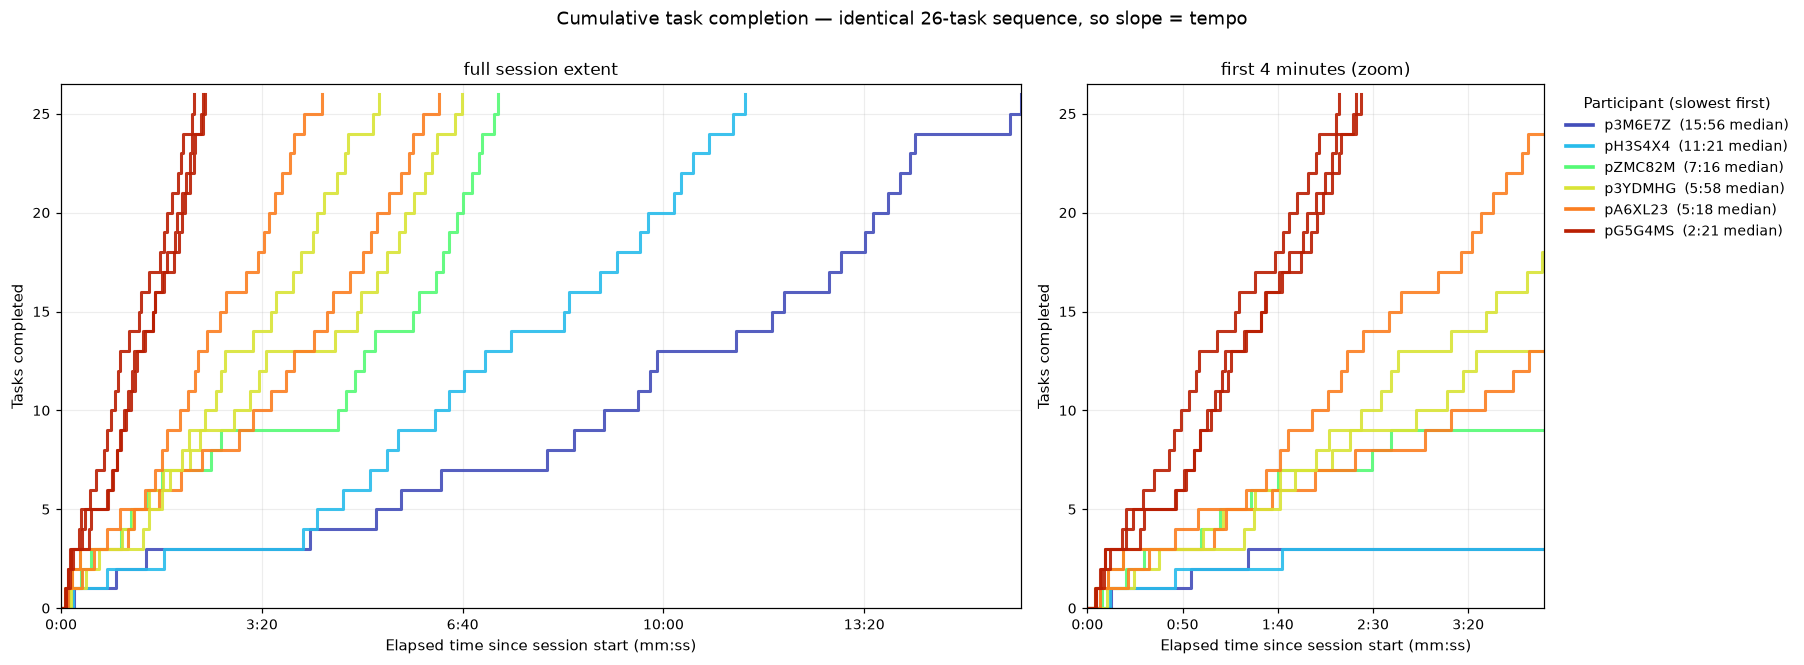

In [3]:
_ts = raw.loc[raw['kind'] == 'task_start',
              ['sessionId', 'participantId', 'taskIndex', 'payload_taskType', 'tRelMs']].copy()
_te = raw.loc[raw['kind'] == 'task_end', ['sessionId', 'taskIndex', 'tRelMs']].copy()
_ts = _ts.rename(columns={'payload_taskType': 'taskType', 'tRelMs': 'task_start_ms'})
_te = _te.rename(columns={'tRelMs': 'task_end_ms'})

task_timeline = _ts.merge(_te, on=['sessionId', 'taskIndex'], how='left')
task_timeline['taskIndex'] = pd.to_numeric(task_timeline['taskIndex'], errors='coerce')
task_timeline['task_start_s'] = task_timeline['task_start_ms'] / 1000.0
task_timeline['task_end_s'] = task_timeline['task_end_ms'] / 1000.0
task_timeline['task_duration_s'] = task_timeline['task_end_s'] - task_timeline['task_start_s']
task_timeline = task_timeline.sort_values(['sessionId', 'taskIndex']).reset_index(drop=True)

N_TASKS = int(task_timeline['taskIndex'].max()) + 1


def plot_cumulative_progress(timeline, sessions_meta, time_range_s=TIME_RANGE_S):
    fig, axes = plt.subplots(1, 2, figsize=(16.5, 6),
                             gridspec_kw={'width_ratios': [2.1, 1]})
    ax, axz = axes

    for sid in SESSION_ORDER:
        tl = timeline.loc[timeline['sessionId'] == sid].sort_values('taskIndex')
        if tl.empty:
            continue
        pid = tl['participantId'].iloc[0]
        x = np.concatenate(([0.0], tl['task_end_s'].to_numpy(float)))
        y = np.arange(0, len(tl) + 1)
        ok = np.isfinite(x)
        for a in (ax, axz):
            a.step(x[ok], y[ok], where='post', color=pcolor(pid), linewidth=2.0, alpha=0.9)

    ax.set_xlim(*time_range_s)
    axz.set_xlim(0, min(240, time_range_s[1]))
    for a, ttl in ((ax, "full session extent"), (axz, "first 4 minutes (zoom)")):
        a.set_ylim(0, N_TASKS + 0.5)
        a.xaxis.set_major_formatter(plt.FuncFormatter(format_elapsed_mmss))
        a.set_xlabel("Elapsed time since session start (mm:ss)")
        a.set_ylabel("Tasks completed")
        a.set_title(ttl)

    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4,
                      label=f"{p}  ({format_elapsed_mmss(_p_dur[p])} median)")
               for p in PARTICIPANT_ORDER]
    axz.legend(handles=handles, title="Participant (slowest first)",
               bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    fig.suptitle("Cumulative task completion — identical 26-task sequence, so slope = tempo", y=1.0)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


plot_cumulative_progress(task_timeline, session_index)

## 3.1 Modality affordance — where each signal is even meaningful

A signal should only be read where the task calls for it. Plotting typing rhythm during a
scrolling task is not measuring a quiet typist; it is measuring nothing, and averaging
that nothing into the distribution drags every participant toward the same value.

**But inactivity has two causes and only one of them is meaningless.** If the task does
not afford typing, no typing is uninformative. If the task *does* afford typing and the
person still is not typing, that silence is hesitation — the strongest signal in this
notebook. So the mask has to key on **what the task affords**, never on **whether events
were observed**. Masking on observed activity would delete exactly the behaviour we are
trying to measure.

The map below is derived from the data rather than hardcoded: for each task type, the
fraction of instances in which the modality produced at least one event. Typing comes out
perfectly bimodal (0% or 100%), so nothing hinges on where the threshold sits. Scrolling
is graded and the borderline cases are flagged for inspection.

In [4]:
TAP_KIND, TAP_END_KIND, MOVE_KIND = 'touchstart', 'touchend', 'touchmove'
KEY_KIND, KEYUP_KIND, INPUT_KIND = 'keydown', 'keyup', 'input'
SCROLL_KINDS = ('scroll', 'window_scroll', 'carousel_scroll')
INTERACTION_KINDS = ('keydown', 'keyup', 'input', 'touchstart', 'touchmove', 'touchend',
                     'pointerdown', 'pointerup', 'pointermove', 'scroll', 'window_scroll',
                     'carousel_scroll', 'click', 'gesture_drag_end', 'pot_drag_release',
                     'approval_swipe_release')

AFFORDANCE_THRESHOLD = 0.5     # task affords a modality if this share of instances show it
AFFORDANCE_BORDERLINE = (0.25, 0.75)   # flagged for inspection rather than trusted
WINDOW_AFFORDANCE_OVERLAP = 0.5        # a window is afforded if this much of it sits in afforded tasks

MODALITY_KINDS = {
    'typing': ['keydown'],
    'tapping': ['touchstart'],
    'scrolling': list(SCROLL_KINDS),
}


def build_affordance_map(raw_df, timeline, threshold=AFFORDANCE_THRESHOLD):
    '''Fraction of instances of each task type in which each modality fired at least once.'''
    rows = []
    for sid, g in raw_df.groupby('sessionId'):
        arrays = {m: np.sort(g.loc[g['kind'].isin(k), 'tRelMs'].to_numpy(float))
                  for m, k in MODALITY_KINDS.items()}
        for r in timeline.loc[timeline['sessionId'] == sid].itertuples():
            if not (np.isfinite(r.task_start_s) and np.isfinite(r.task_end_s)):
                continue
            lo, hi = r.task_start_s * 1000.0, r.task_end_s * 1000.0
            rec = {'taskType': r.taskType, 'sessionId': sid}
            for m, a in arrays.items():
                rec[m] = int(((a >= lo) & (a < hi)).sum())
            rows.append(rec)
    inst = pd.DataFrame(rows)
    frac = inst.groupby('taskType')[list(MODALITY_KINDS)].apply(lambda d: (d > 0).mean())
    frac['n_instances'] = inst.groupby('taskType').size()
    return inst, frac


task_instances, affordance_frac = build_affordance_map(raw, task_timeline)

AFFORDS = {m: set(affordance_frac.index[affordance_frac[m] >= AFFORDANCE_THRESHOLD])
           for m in MODALITY_KINDS}

_lo, _hi = AFFORDANCE_BORDERLINE
_border = {m: sorted(affordance_frac.index[(affordance_frac[m] > _lo) & (affordance_frac[m] < _hi)])
           for m in MODALITY_KINDS}

print("Share of task instances in which each modality fired at least once:\n")
print((affordance_frac[list(MODALITY_KINDS)] * 100).round(0).astype(int).to_string())
print()
for m in MODALITY_KINDS:
    print(f"{m:10s} afforded by {len(AFFORDS[m])}/{len(affordance_frac)} task types: "
          f"{', '.join(sorted(AFFORDS[m])) if AFFORDS[m] else '(none)'}")
    if _border[m]:
        print(f"{'':10s} BORDERLINE ({int(_lo*100)}-{int(_hi*100)}%), check before trusting: "
              f"{', '.join(_border[m])}")

Share of task instances in which each modality fired at least once:

                  typing  tapping  scrolling
taskType                                    
activity_filter        0      100         55
card_swipe             0      100        100
categorise             0      100        100
code                   0      100        100
finish                 0      100         60
guided_note          100      100        100
guided_reply         100      100        100
home_explore           0      100        100
insights_review        0      100        100
pot_drag               0      100         75
pots_transfer        100      100        100
swipe_approval         0      100         70
tap_account            0      100         20
transaction_feed       0      100        100
typing_search        100      100        100

typing     afforded by 4/15 task types: guided_note, guided_reply, pots_transfer, typing_search
tapping    afforded by 15/15 task types: activity_filter, card_swipe,

### 3.2 Marking every window with what its task afforded

A 7.5s window can straddle a task boundary, so affordance is a matter of degree. The rule
here is **majority overlap**: a window counts as afforded if more than half of it falls
inside tasks that afford the modality. The permissive alternative — any overlap at all —
is available by lowering `WINDOW_AFFORDANCE_OVERLAP`, and is worth trying if it turns out
to matter, but the strict rule is the safer default because it keeps a window's label
aligned with where most of its events actually came from.

In [5]:
def afforded_overlap_fraction(timeline, session_id, lo_s, hi_s, task_set):
    '''How much of [lo_s, hi_s) lies inside tasks that afford this modality.'''
    span = hi_s - lo_s
    if span <= 0:
        return 0.0
    t = timeline.loc[(timeline['sessionId'] == session_id)
                     & (timeline['taskType'].isin(task_set))]
    if t.empty:
        return 0.0
    starts = t['task_start_s'].to_numpy(float)
    ends = t['task_end_s'].to_numpy(float)
    ok = np.isfinite(starts) & np.isfinite(ends)
    overlap = np.clip(np.minimum(ends[ok], hi_s) - np.maximum(starts[ok], lo_s), 0, None).sum()
    return float(overlap / span)


def add_window_affordance(win_df, timeline, window_s):
    out = win_df.copy()
    for m, task_set in AFFORDS.items():
        col = f'{m}_afforded'
        vals = np.empty(len(out), dtype=bool)
        for i, r in enumerate(out.itertuples()):
            frac = afforded_overlap_fraction(timeline, r.sessionId,
                                             r.window_start_s, r.window_start_s + window_s,
                                             task_set)
            vals[i] = frac >= WINDOW_AFFORDANCE_OVERLAP
        out[col] = vals
    return out

## 4. The interaction raster

One tick per interaction event, no binning and no aggregation — the closest thing to
looking directly at the raw stream. Three lanes per session: typing, tapping, scrolling.

Read the **white space**. Dense black is continuous interaction; every gap is a pause.
This is the plot where the pauses that dominate a slow session become the visually
dominant feature, because idle time is drawn as itself rather than as an absence of
data points.

Sessions are ordered slowest-first, so the gradient runs top to bottom.

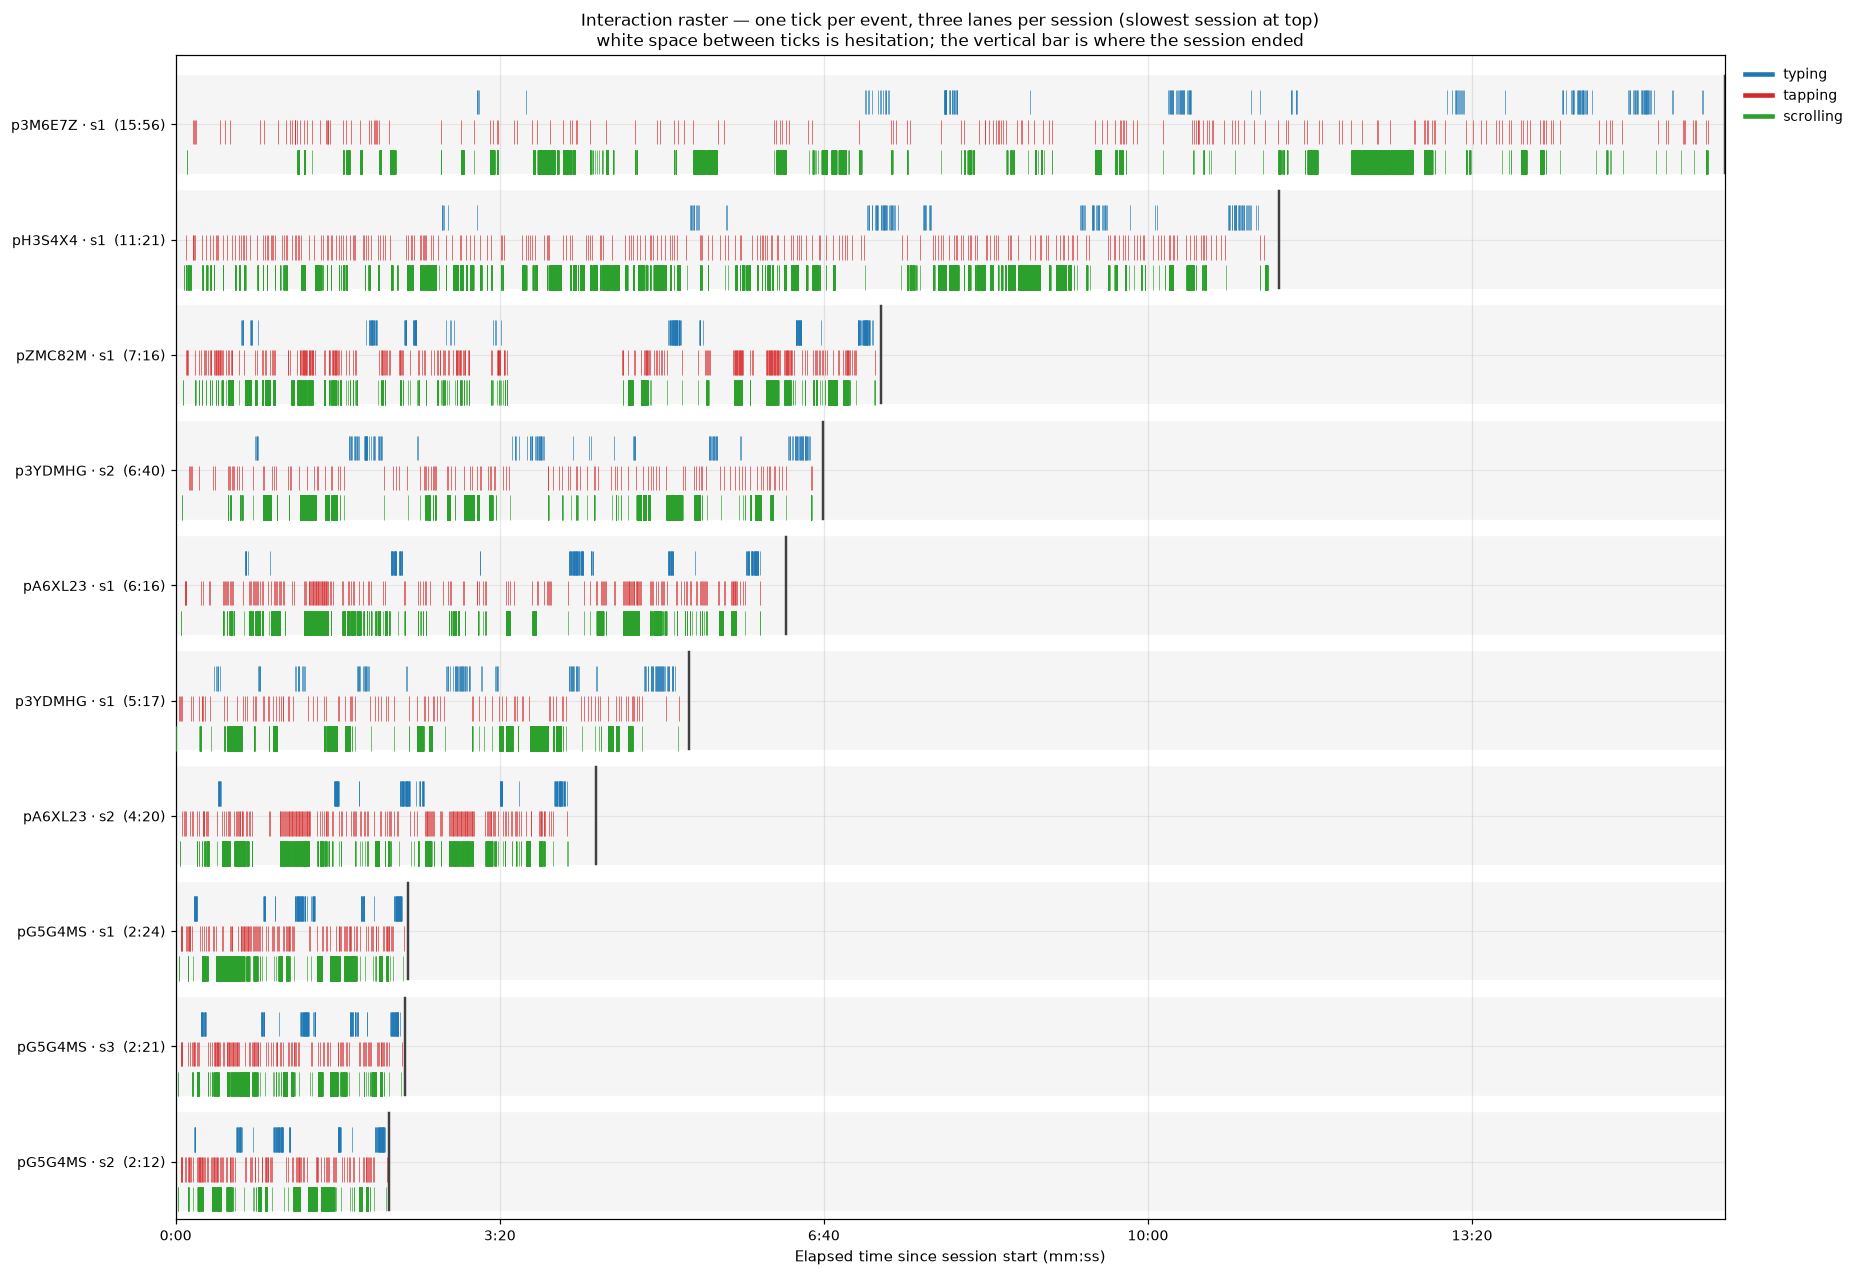

In [6]:
LANES = [('typing', (KEY_KIND,), '#1f77b4'),
         ('tapping', (TAP_KIND,), '#d62728'),
         ('scrolling', SCROLL_KINDS, '#2ca02c')]


def plot_interaction_raster(raw_df, time_range_s=TIME_RANGE_S, lane_h=0.26):
    n = len(SESSION_ORDER)
    fig, ax = plt.subplots(figsize=(17, 0.95 * n + 2.2))

    for row, sid in enumerate(SESSION_ORDER):
        sub = raw_df.loc[raw_df['sessionId'] == sid]
        dur = float(sub['tRelMs'].max()) / 1000.0
        base = row
        ax.axhspan(base - 0.42, base + 0.42, color='0.96', zorder=0)
        # session extent marker so a short session reads as "ended", not "silent"
        ax.plot([dur, dur], [base - 0.42, base + 0.42], color='0.25', lw=1.6, zorder=4)
        for li, (name, kinds, colr) in enumerate(LANES):
            t = sub.loc[sub['kind'].isin(kinds), 'tRelMs'].to_numpy(float) / 1000.0
            if len(t) == 0:
                continue
            y = base - 0.30 + li * lane_h
            ax.vlines(t, y, y + lane_h * 0.82, color=colr, linewidth=0.55,
                      alpha=0.75, rasterized=True, zorder=3)

    ax.set_yticks(range(n))
    ax.set_yticklabels([f"{SESSION_LABEL[s]}  ({format_elapsed_mmss(session_index.set_index('sessionId').loc[s, 'duration_s'])})"
                        for s in SESSION_ORDER])
    ax.invert_yaxis()
    ax.set_ylim(n - 0.5, -0.6)
    ax.set_xlim(*time_range_s)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(format_elapsed_mmss))
    ax.set_xlabel("Elapsed time since session start (mm:ss)")
    ax.set_title("Interaction raster — one tick per event, three lanes per session "
                 "(slowest session at top)\nwhite space between ticks is hesitation; "
                 "the vertical bar is where the session ended")
    ax.grid(True, axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    handles = [Line2D([0], [0], color=c, lw=3, label=nm) for nm, _, c in LANES]
    ax.legend(handles=handles, bbox_to_anchor=(1.005, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


plot_interaction_raster(raw)

## 5. Rhythm feature extraction

Everything below is computed over a time window rather than per event, because rates and
silences only exist at the window level. Timestamps are pre-extracted per session into
sorted arrays and sliced with `searchsorted`, so the whole sweep is a fraction of a
second rather than a groupby per window.

Two window sizes are used deliberately:

- **`PLOT_WINDOW_S` (20s / 5s stride)** for readable trajectories. At P2's operational
  7.5s the per-window event counts are too small for a stable percentile and the plots
  become noise.
- **`CA_WINDOW_S` (7.5s / 2.5s stride)**, P2's actual windowing, used in Section 9 to ask
  the operational question: could a *single* authentication window separate these people?

`idle_fraction` counts the window edges, so a window containing no events at all scores
1.0 rather than NaN. That is the correct answer — total silence is a strong observation,
not a missing one — and it is the specific thing notebook 03 could not represent.

**Affordance masking applies to rate features only, and the reason is mechanical.** A rate
has time in its denominator, so when a modality is not afforded it returns a real-looking
`0` that is indistinguishable from a measured zero — and since every participant scores 0
during a scrolling task, those windows are shared dead weight that compresses everyone
toward the same value. An interval feature has *events* in its denominator, so it is
already NaN when nothing happened; masking it changes nothing. Section 5.1 measures this
rather than assuming it.

In [7]:
IDLE_GAP_MS = 2000.0          # a pause longer than this counts as hesitation
SCROLL_BURST_GAP_MS = 1000.0  # scroll events separated by more than this start a new burst

PLOT_WINDOW_S, PLOT_STRIDE_S = 20.0, 5.0
CA_WINDOW_S, CA_STRIDE_S = 7.5, 2.5


def _slice(arr, lo, hi):
    return arr[np.searchsorted(arr, lo):np.searchsorted(arr, hi)]


def _q(v, p):
    return float(np.percentile(v, p)) if len(v) >= 2 else np.nan


def _idle_fraction(t, lo, hi, gap_ms=IDLE_GAP_MS):
    span = hi - lo
    if span <= 0:
        return np.nan
    if len(t) == 0:
        return 1.0
    gaps = np.diff(np.concatenate(([lo], t, [hi])))
    return float(gaps[gaps > gap_ms].sum() / span)


def _longest_gap_s(t, lo, hi):
    if len(t) == 0:
        return (hi - lo) / 1000.0
    return float(np.diff(np.concatenate(([lo], t, [hi]))).max() / 1000.0)


def _paired_hold(starts, ends):
    '''Stack-matched start->end durations; same O(n) pairing as notebook 03.'''
    if len(starts) == 0 or len(ends) == 0:
        return np.array([])
    ev = [(t, 0) for t in starts] + [(t, 1) for t in ends]
    ev.sort(key=lambda e: (e[0], e[1]))
    stack, out = [], []
    for t, k in ev:
        if k == 0:
            stack.append(t)
        elif stack:
            out.append(t - stack.pop())
    return np.asarray(out, dtype=float)


def _bursts(t, gap_ms=SCROLL_BURST_GAP_MS):
    if len(t) == 0:
        return 0, np.nan
    parts = np.split(t, np.where(np.diff(t) > gap_ms)[0] + 1)
    return len(parts), float(np.mean([len(p) for p in parts]))


def session_arrays(sub):
    a = {k: np.sort(sub.loc[sub['kind'] == k, 'tRelMs'].to_numpy(float))
         for k in set(INTERACTION_KINDS)}
    a['_scroll'] = np.sort(np.concatenate([a.get(k, np.array([])) for k in SCROLL_KINDS]))
    a['_interaction'] = np.sort(np.concatenate([a.get(k, np.array([])) for k in INTERACTION_KINDS]))
    inp = sub.loc[sub['kind'] == INPUT_KIND].sort_values('tRelMs')
    a['_input_t'] = inp['tRelMs'].to_numpy(float)
    a['_input_delta'] = pd.to_numeric(inp.get('payload_deltaLength'), errors='coerce').to_numpy(float)
    return a


def rhythm_features(a, lo, hi):
    span_s = (hi - lo) / 1000.0
    inter = _slice(a['_interaction'], lo, hi)
    taps = _slice(a[TAP_KIND], lo, hi)
    tap_ends = _slice(a[TAP_END_KIND], lo, hi)
    keys = _slice(a[KEY_KIND], lo, hi)
    keyups = _slice(a[KEYUP_KIND], lo, hi)
    scrolls = _slice(a['_scroll'], lo, hi)
    moves = _slice(a[MOVE_KIND], lo, hi)

    itap = np.diff(taps) if len(taps) > 1 else np.array([])
    ptp = np.diff(keys) if len(keys) > 1 else np.array([])
    hold = _paired_hold(taps, tap_ends)
    dwell = _paired_hold(keys, keyups)
    n_burst, per_burst = _bursts(scrolls)

    m = (a['_input_t'] >= lo) & (a['_input_t'] < hi)
    deltas = a['_input_delta'][m]
    deltas = deltas[np.isfinite(deltas)]

    return {
        # ---- tempo: when things happen, and what happens in the silences ----
        'idle_fraction': _idle_fraction(inter, lo, hi),
        'longest_gap_s': _longest_gap_s(inter, lo, hi),
        'interaction_rate': len(inter) / span_s,
        'tap_rate': len(taps) / span_s,
        'key_rate': len(keys) / span_s,
        'scroll_rate': len(scrolls) / span_s,
        'inter_tap_p50': _q(itap, 50),
        'inter_tap_p90': _q(itap, 90),
        'press_to_press_p50': _q(ptp, 50),
        'press_to_press_p90': _q(ptp, 90),
        'touchmove_per_tap': (len(moves) / len(taps)) if len(taps) else np.nan,
        'correction_rate': float((deltas < 0).mean()) if len(deltas) else np.nan,
        'scroll_burst_rate': n_burst / span_s,
        'scroll_events_per_burst': per_burst,
        # ---- amplitude: what notebook 03 already plots, kept for the comparison ----
        'touch_hold_p50': _q(hold, 50),
        'touch_hold_p90': _q(hold, 90),
        'typing_dwell_p50': _q(dwell, 50),
    }


TEMPO_FEATURES = ['idle_fraction', 'longest_gap_s', 'interaction_rate', 'tap_rate',
                  'key_rate', 'scroll_rate', 'inter_tap_p50', 'inter_tap_p90',
                  'press_to_press_p50', 'press_to_press_p90', 'touchmove_per_tap',
                  'correction_rate', 'scroll_burst_rate', 'scroll_events_per_burst']
AMPLITUDE_FEATURES = ['touch_hold_p50', 'touch_hold_p90', 'typing_dwell_p50']
ALL_FEATURES = TEMPO_FEATURES + AMPLITUDE_FEATURES

LOG_SCALE_FEATURES = {'inter_tap_p50', 'inter_tap_p90', 'press_to_press_p50',
                      'press_to_press_p90', 'longest_gap_s', 'touch_hold_p50',
                      'touch_hold_p90', 'touchmove_per_tap'}

FEATURE_UNITS = {
    'idle_fraction': 'fraction of window', 'longest_gap_s': 's', 'interaction_rate': 'events/s',
    'tap_rate': 'taps/s', 'key_rate': 'keys/s', 'scroll_rate': 'scroll events/s',
    'inter_tap_p50': 'ms', 'inter_tap_p90': 'ms', 'press_to_press_p50': 'ms',
    'press_to_press_p90': 'ms', 'touchmove_per_tap': 'moves/tap', 'correction_rate': 'fraction',
    'scroll_burst_rate': 'bursts/s', 'scroll_events_per_burst': 'events',
    'touch_hold_p50': 'ms', 'touch_hold_p90': 'ms', 'typing_dwell_p50': 'ms',
}


def build_rhythm_windows(raw_df, window_s, stride_s):
    rows = []
    W, S = window_s * 1000.0, stride_s * 1000.0
    for sid, sub in raw_df.groupby('sessionId'):
        a = session_arrays(sub)
        dur = float(sub['tRelMs'].max())
        pid = sub['participantId'].iloc[0]
        lo = 0.0
        while lo + W <= dur:
            f = rhythm_features(a, lo, lo + W)
            f.update(sessionId=sid, participantId=pid,
                     window_start_s=lo / 1000.0, window_mid_s=(lo + W / 2) / 1000.0)
            rows.append(f)
            lo += S
    return pd.DataFrame(rows)


def build_session_level(raw_df):
    rows = []
    for sid, sub in raw_df.groupby('sessionId'):
        a = session_arrays(sub)
        f = rhythm_features(a, 0.0, float(sub['tRelMs'].max()))
        f.update(sessionId=sid, participantId=sub['participantId'].iloc[0],
                 duration_s=float(sub['tRelMs'].max()) / 1000.0)
        rows.append(f)
    return pd.DataFrame(rows)


# Which modality each rate feature belongs to. 'always' means the modality is afforded
# by every task type (tapping is), so the feature never needs masking.
RATE_FEATURE_MODALITY = {
    'key_rate': 'typing',
    'scroll_rate': 'scrolling',
    'scroll_burst_rate': 'scrolling',
    'scroll_events_per_burst': 'scrolling',
    'tap_rate': 'tapping',
    'interaction_rate': 'always',
    'idle_fraction': 'always',
    'longest_gap_s': 'always',
}


def apply_affordance_mask(win_df, mapping=RATE_FEATURE_MODALITY):
    '''NaN out a rate feature wherever its modality was not afforded by the task.

    Deliberately NOT applied to interval features: those are already NaN without
    events, and masking them would additionally discard genuine observations that
    happened to occur inside a task not normally associated with that modality.'''
    out = win_df.copy()
    masked = {}
    for feat, modality in mapping.items():
        if feat not in out.columns or modality == 'always':
            continue
        col = f'{modality}_afforded'
        if col not in out.columns:
            continue
        n_before = out[feat].notna().sum()
        out.loc[~out[col], feat] = np.nan
        masked[feat] = n_before - out[feat].notna().sum()
    return out, masked


session_features = build_session_level(raw)

plot_windows = add_window_affordance(
    build_rhythm_windows(raw, PLOT_WINDOW_S, PLOT_STRIDE_S), task_timeline, PLOT_WINDOW_S)
ca_windows_unmasked = add_window_affordance(
    build_rhythm_windows(raw, CA_WINDOW_S, CA_STRIDE_S), task_timeline, CA_WINDOW_S)

plot_windows, _m1 = apply_affordance_mask(plot_windows)
ca_windows, masked_counts = apply_affordance_mask(ca_windows_unmasked)

print(f"session-level rows: {len(session_features)}")
print(f"{PLOT_WINDOW_S:.0f}s/{PLOT_STRIDE_S:.0f}s plotting windows: {len(plot_windows):,}")
print(f"{CA_WINDOW_S}s/{CA_STRIDE_S}s CA windows: {len(ca_windows):,}\n")

for m in MODALITY_KINDS:
    col = f'{m}_afforded'
    if col in ca_windows:
        print(f"  {m:10s} afforded in {ca_windows[col].mean():6.1%} of CA windows")
print()
for feat, n in masked_counts.items():
    if n:
        print(f"  masked {n:5d} unafforded values from {feat}")

session-level rows: 10
20s/5s plotting windows: 734
7.5s/2.5s CA windows: 1,511

  typing     afforded in  51.5% of CA windows
  tapping    afforded in  99.7% of CA windows
  scrolling  afforded in  96.0% of CA windows

  masked   733 unafforded values from key_rate
  masked    60 unafforded values from scroll_rate
  masked    60 unafforded values from scroll_burst_rate
  masked    28 unafforded values from scroll_events_per_burst
  masked     4 unafforded values from tap_rate


## 5.1 Does the mask actually help?

The claim is that masking sharpens rate features and does nothing to interval features.
Both halves are testable, so here they are, as mean and worst-case pairwise AUC over every
participant pair before and after masking.

The expected result is a split: rate features improve, interval features are unchanged to
three decimals. If an interval feature moves at all, the mask is reaching further than it
should and `RATE_FEATURE_MODALITY` needs correcting.

In [8]:
def rank_auc(x, y):
    '''P(random x > random y), ties counted as half. Equivalent to Mann-Whitney U / (n*m).'''
    x = np.asarray(x, float); y = np.asarray(y, float)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    if len(x) < 5 or len(y) < 5:
        return np.nan
    ranks = pd.Series(np.concatenate([x, y])).rank(method='average').to_numpy()
    rx = ranks[:len(x)].sum()
    # Direction-sensitive: 0.0 means every x fell below every y. Callers take
    # max(auc, 1 - auc) when only separability, not direction, is wanted.
    return float((rx - len(x) * (len(x) + 1) / 2) / (len(x) * len(y)))


def _mean_min_auc(win_df, feature, parts=None):
    parts = sorted(win_df['participantId'].unique()) if parts is None else parts
    vals = {p: win_df.loc[win_df['participantId'] == p, feature].to_numpy(float) for p in parts}
    scores = []
    for i, a in enumerate(parts):
        for b in parts[i + 1:]:
            v = rank_auc(vals[a], vals[b])
            if np.isfinite(v):
                scores.append(max(v, 1 - v))
    if not scores:
        return np.nan, np.nan
    return float(np.mean(scores)), float(np.min(scores))


_check = ['key_rate', 'scroll_rate', 'scroll_burst_rate', 'scroll_events_per_burst',
          'press_to_press_p50', 'press_to_press_p90', 'typing_dwell_p50',
          'correction_rate', 'inter_tap_p50', 'touch_hold_p50']

rows = []
for f in _check:
    if f not in ca_windows.columns:
        continue
    m0, n0 = _mean_min_auc(ca_windows_unmasked, f)
    m1, n1 = _mean_min_auc(ca_windows, f)
    rows.append({'feature': f,
                 'class': 'rate' if f in RATE_FEATURE_MODALITY else 'interval',
                 'auc_mean_unmasked': m0, 'auc_mean_masked': m1, 'delta_mean': m1 - m0,
                 'auc_min_unmasked': n0, 'auc_min_masked': n1})
mask_effect = pd.DataFrame(rows).sort_values('delta_mean', ascending=False).reset_index(drop=True)

_moved = mask_effect.loc[(mask_effect['class'] == 'interval')
                         & (mask_effect['delta_mean'].abs() > 1e-9), 'feature'].tolist()
if _moved:
    print(f"WARNING: masking moved interval features {_moved} — it is reaching too far. "
          f"Check RATE_FEATURE_MODALITY.")
else:
    print("As expected: interval features unchanged by masking (they were already "
          "self-masking via a per-event denominator).")
mask_effect.round(3)

As expected: interval features unchanged by masking (they were already self-masking via a per-event denominator).


,feature,class,auc_mean_unmasked,auc_mean_masked,delta_mean,auc_min_unmasked,auc_min_masked
0,key_rate,rate,0.579,0.661,0.082,0.506,0.522
1,scroll_events_per_burst,rate,0.550,0.550,0.000,0.507,0.508
2,press_to_press_p50,interval,0.786,0.786,0.000,0.513,0.513
3,press_to_press_p90,interval,0.780,0.780,0.000,0.546,0.546
4,typing_dwell_p50,interval,0.749,0.749,0.000,0.514,0.514
5,correction_rate,interval,0.591,0.591,0.000,0.504,0.504
6,inter_tap_p50,interval,0.716,0.716,0.000,0.515,0.515
7,touch_hold_p50,interval,0.613,0.613,0.000,0.503,0.503
8,scroll_rate,rate,0.619,0.618,-0.001,0.509,0.520
9,scroll_burst_rate,rate,0.628,0.625,-0.003,0.507,0.510


### 5.2 Afforded-but-silent is the signal, and it survives

The check that matters most. Within windows the task *did* afford, how often is the
modality still silent? Those windows are the person sitting in a typing task not typing —
hesitation, and the single strongest thing in this dataset.

Had the mask keyed on observed activity rather than task affordance, every one of these
would have been deleted.

In [9]:
for m, feat in [('typing', 'key_rate'), ('scrolling', 'scroll_rate')]:
    col = f'{m}_afforded'
    if col not in ca_windows or feat not in ca_windows:
        continue
    aff = ca_windows.loc[ca_windows[col]]
    silent = (aff[feat].fillna(0) == 0).mean()
    print(f"{m:10s}: afforded in {ca_windows[col].mean():5.1%} of windows; "
          f"of those, {silent:5.1%} are silent anyway -> retained as hesitation")

_kept = int(((ca_windows['typing_afforded']) & (ca_windows['key_rate'].fillna(0) == 0)).sum())
print(f"\nWindows kept that an activity-based mask would have discarded: {_kept:,}")

typing    : afforded in 51.5% of windows; of those, 47.9% are silent anyway -> retained as hesitation
scrolling : afforded in 96.0% of windows; of those, 18.7% are silent anyway -> retained as hesitation

Windows kept that an activity-based mask would have discarded: 373


## 6. Why notebook 03 missed it — tempo vs amplitude, scored

The claim of this notebook is falsifiable, so here it is as a number.

For each feature, the **effect size** is the gap between the slow and fast participant
divided by the **pooled within-participant, across-session standard deviation**. The
denominator is the point: it asks how far apart these two people are *relative to how
much a single person varies between their own sessions*. A ratio of raw values would
reward any feature with a big scale; this doesn't.

Features carrying `amplitude` are the ones notebook 03 already plots. If the diagnosis
at the top of this notebook is right, they should sit at the bottom of this table.

In [10]:
def pooled_within_sd(df, feature, group='participantId'):
    '''SD of a feature across a participant's own sessions, pooled over participants.
    Requires repeat sessions; participants with one session contribute nothing.'''
    sds = [g[feature].std(ddof=1) for _, g in df.groupby(group)
           if len(g) > 1 and np.isfinite(g[feature].std(ddof=1))]
    return float(np.sqrt(np.mean(np.square(sds)))) if sds else np.nan


def contrast_table(sess_df, slow=None, fast=None, features=ALL_FEATURES):
    slow = CONTRAST_SLOW if slow is None else slow
    fast = CONTRAST_FAST if fast is None else fast
    rows = []
    for f in features:
        d = sess_df[['participantId', f]].dropna()
        if d.empty:
            continue
        sd = pooled_within_sd(d, f)
        a = d.loc[d['participantId'] == slow, f].mean()
        b = d.loc[d['participantId'] == fast, f].mean()
        eff = abs(a - b) / sd if (sd and np.isfinite(sd) and sd > 0) else np.nan
        rows.append({'feature': f,
                     'kind': 'tempo' if f in TEMPO_FEATURES else 'amplitude',
                     'unit': FEATURE_UNITS.get(f, ''),
                     f'{slow} (slow)': a, f'{fast} (fast)': b,
                     'within_participant_sd': sd, 'effect_size': eff})
    return (pd.DataFrame(rows).sort_values('effect_size', ascending=False)
            .reset_index(drop=True))


contrast = contrast_table(session_features)
_show = contrast.copy()
for c in _show.columns:
    if _show[c].dtype.kind == 'f':
        _show[c] = _show[c].round(3)

print(f"Slow: {CONTRAST_SLOW}   Fast: {CONTRAST_FAST}")
print("Effect size = |slow - fast| / pooled within-participant SD across sessions.\n")
_rank = contrast.dropna(subset=['effect_size'])
_amp_rank = _rank.loc[_rank['kind'] == 'amplitude', 'feature'].tolist()
print(f"Top 3 features, all tempo: {', '.join(_rank.head(3)['feature'])}")
print(f"Amplitude features (what notebook 03 plots) rank: "
      f"{[int(_rank.reset_index().index[_rank.reset_index()['feature'] == f][0]) + 1 for f in _amp_rank]}"
      f" of {len(_rank)}")
_show

Slow: p3M6E7Z   Fast: pG5G4MS
Effect size = |slow - fast| / pooled within-participant SD across sessions.

Top 3 features, all tempo: inter_tap_p50, longest_gap_s, press_to_press_p90
Amplitude features (what notebook 03 plots) rank: [6, 16, 17] of 17


,feature,kind,unit,p3M6E7Z (slow),pG5G4MS (fast),within_participant_sd,effect_size
0,inter_tap_p50,tempo,ms,2531.000,634.333,68.602,27.647
1,longest_gap_s,tempo,s,31.004,2.898,1.045,26.891
2,press_to_press_p90,tempo,ms,2741.600,464.233,104.112,21.874
3,press_to_press_p50,tempo,ms,448.500,172.333,14.898,18.537
4,interaction_rate,tempo,events/s,11.305,21.937,0.651,16.329
5,touch_hold_p90,amplitude,ms,1809.600,355.033,105.151,13.833
6,key_rate,tempo,keys/s,0.173,0.854,0.056,12.091
7,inter_tap_p90,tempo,ms,11617.200,2302.133,986.098,9.446
8,scroll_burst_rate,tempo,bursts/s,0.086,0.199,0.012,9.328
9,idle_fraction,tempo,fraction of window,0.566,0.041,0.067,7.829


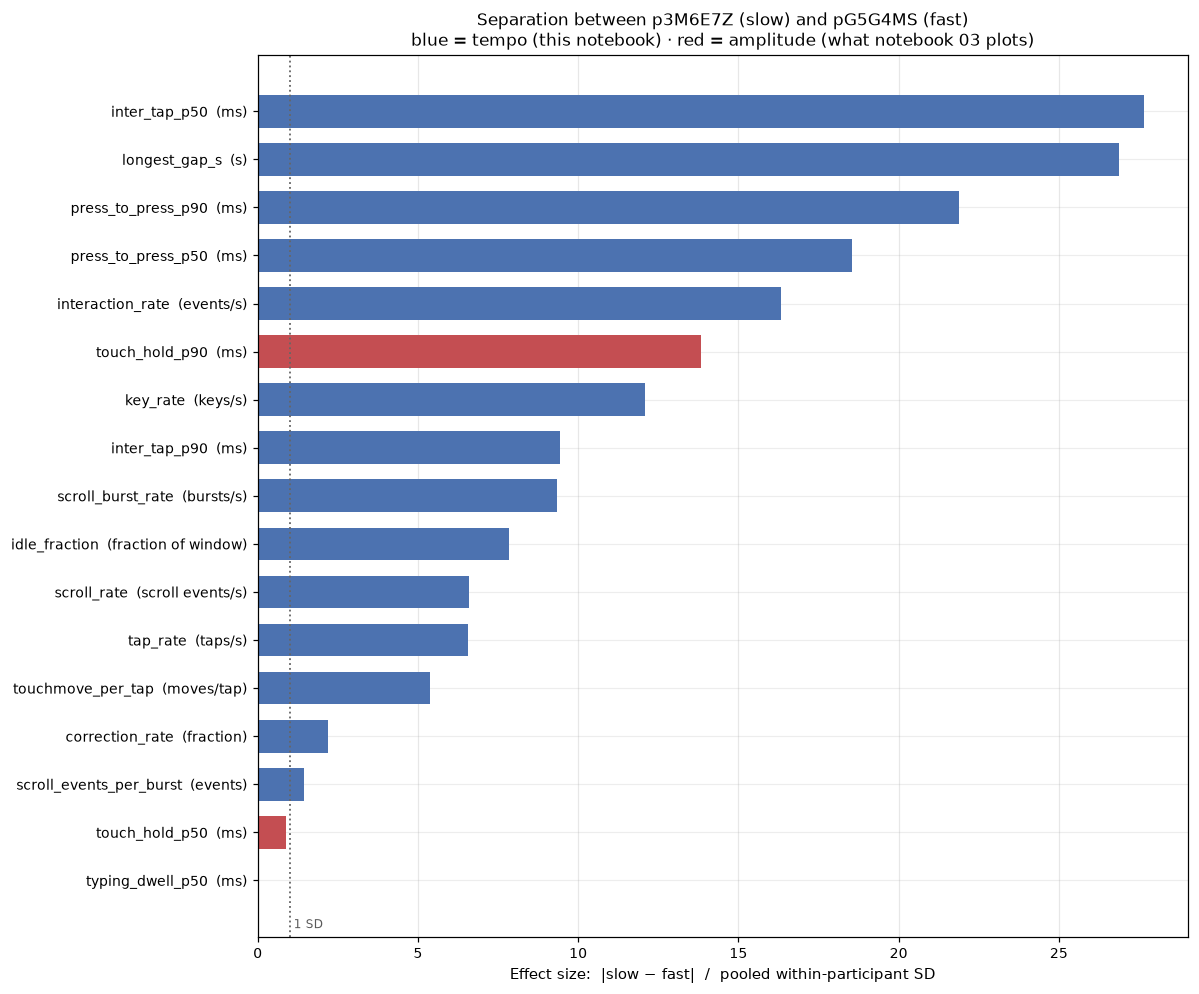

In [11]:
def plot_contrast_bars(contrast_df):
    d = contrast_df.dropna(subset=['effect_size']).sort_values('effect_size')
    fig, ax = plt.subplots(figsize=(11, 0.42 * len(d) + 2))
    colors = ['#c44e52' if k == 'amplitude' else '#4c72b0' for k in d['kind']]
    ax.barh(range(len(d)), d['effect_size'], color=colors, height=0.68)
    ax.set_yticks(range(len(d)))
    ax.set_yticklabels([f"{r.feature}  ({r.unit})" for r in d.itertuples()])
    ax.set_xlabel("Effect size:  |slow − fast|  /  pooled within-participant SD")
    ax.set_title(f"Separation between {CONTRAST_SLOW} (slow) and {CONTRAST_FAST} (fast)\n"
                 "blue = tempo (this notebook) · red = amplitude (what notebook 03 plots)")
    ax.axvline(1.0, color='0.4', ls=':', lw=1.2)
    ax.text(1.0, -0.8, " 1 SD", fontsize=8, color='0.35', va='top')
    ax.grid(True, axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


plot_contrast_bars(contrast)

## 7. Rhythm over session time

The tempo features on the shared elapsed-time axis, so the question "is this person
consistently slow, or did they stall once" can actually be answered. Log scale where the
feature spans orders of magnitude.

Each faint line is a session; the bold line is the participant median across their
sessions.

**Lines break where the modality was not afforded.** A masked feature is NaN outside its
afforded tasks, so matplotlib gaps the line rather than drawing a segment straight across
a stretch where the signal did not exist. The shaded bands mark where the modality *was*
afforded, taken as the median task boundaries across sessions — indicative only, since
session lengths differ by 7x.

The support strip is now **per modality**: it counts sessions that are both still running
*and* inside an afforded task, which is the correct denominator for a masked feature.
Counting every running session would overstate support for exactly the windows the mask
just removed.

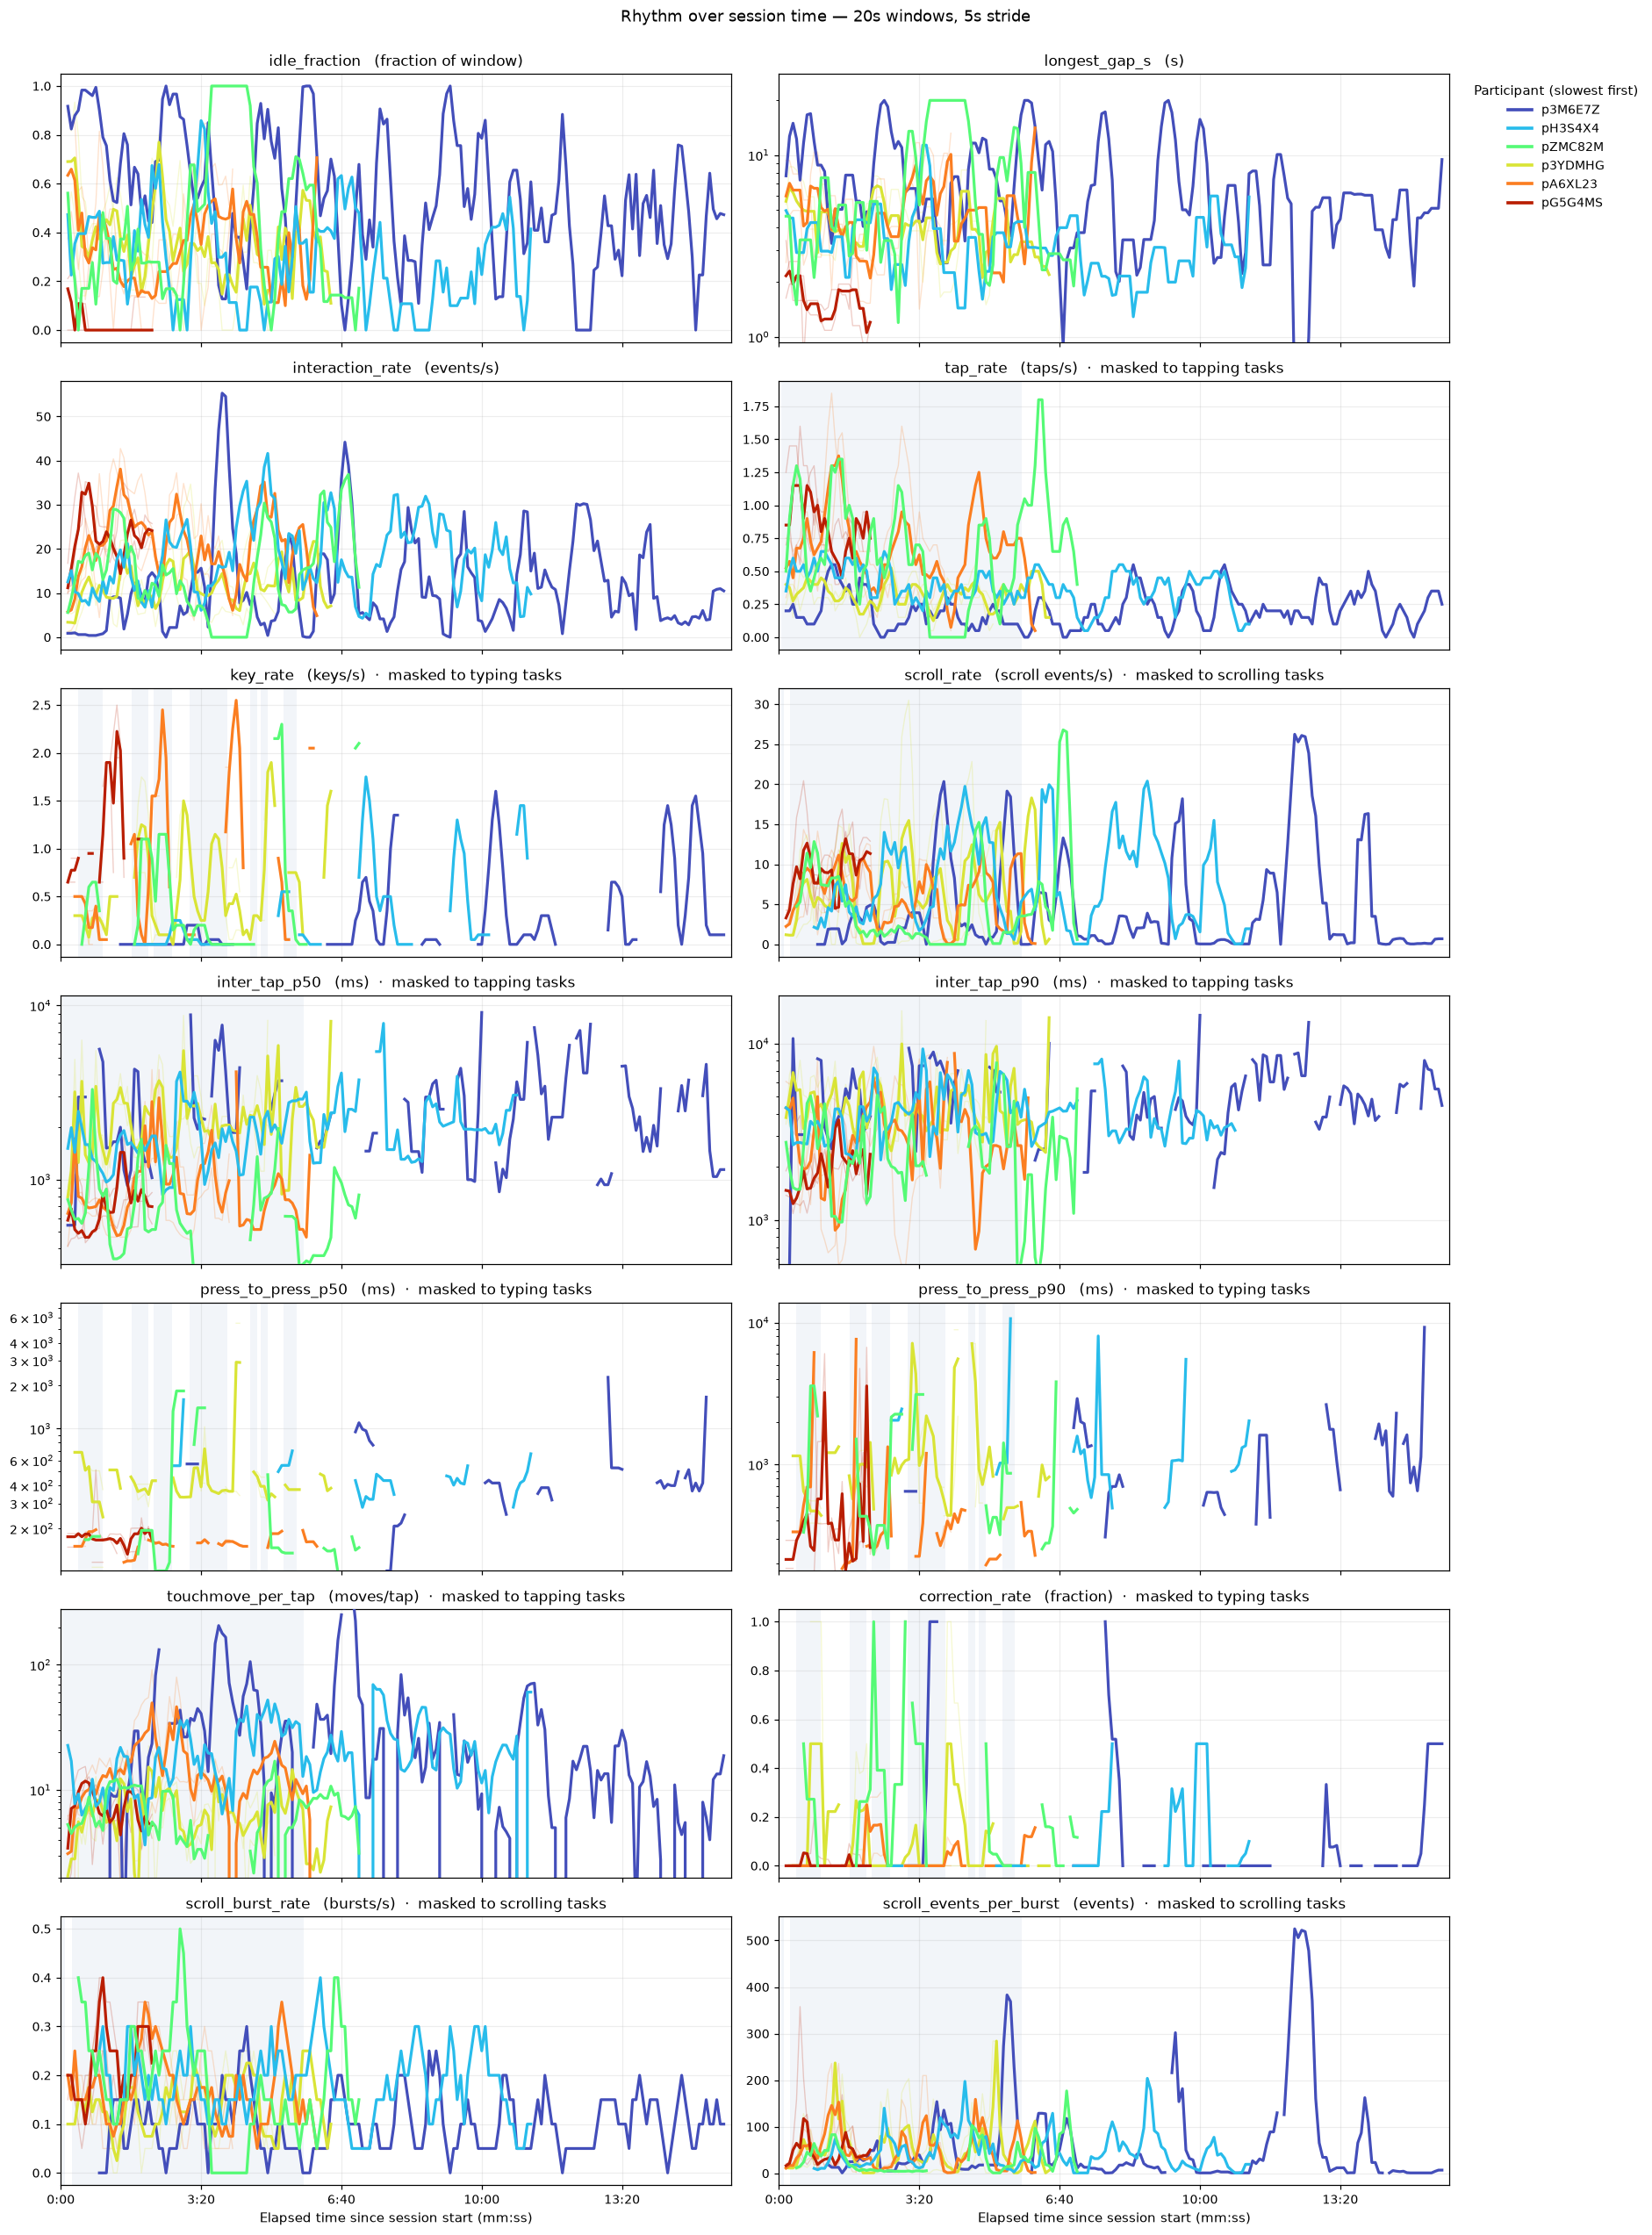

In [12]:
FEATURE_MODALITY = dict(RATE_FEATURE_MODALITY)
FEATURE_MODALITY.update({
    'inter_tap_p50': 'tapping', 'inter_tap_p90': 'tapping', 'touchmove_per_tap': 'tapping',
    'touch_hold_p50': 'tapping', 'touch_hold_p90': 'tapping',
    'press_to_press_p50': 'typing', 'press_to_press_p90': 'typing',
    'typing_dwell_p50': 'typing', 'correction_rate': 'typing',
})


def session_support_by_bin(sessions_meta, bin_s, time_range_s=TIME_RANGE_S, modality=None):
    '''Sessions still running in each bin. With a modality, additionally requires the
    session to be inside a task that affords it — the right denominator for a masked
    feature, since counting every running session would overstate support for exactly
    the windows the mask removed.'''
    edges = np.arange(time_range_s[0], time_range_s[1] + bin_s, bin_s)
    mids = edges[:-1] + bin_s / 2.0
    running = np.array([(sessions_meta['duration_s'] >= m).sum() for m in mids])
    if modality is None or modality == 'always' or modality not in AFFORDS:
        return pd.DataFrame({'mid': mids, 'n': running})
    tasks = task_timeline.loc[task_timeline['taskType'].isin(AFFORDS[modality])]
    counts = np.zeros(len(mids), dtype=int)
    for sid, g in tasks.groupby('sessionId'):
        spans = g[['task_start_s', 'task_end_s']].to_numpy(float)
        spans = spans[np.isfinite(spans).all(1)]
        inside = np.zeros(len(mids), dtype=bool)
        for lo, hi in spans:
            inside |= (mids >= lo) & (mids < hi)
        counts += inside.astype(int)
    return pd.DataFrame({'mid': mids, 'n': np.minimum(counts, running)})


def shade_afforded(ax, modality, alpha=0.07):
    '''Median task boundaries for the tasks that afford this modality.'''
    if modality is None or modality == 'always' or modality not in AFFORDS:
        return
    tl = task_timeline.loc[task_timeline['taskType'].isin(AFFORDS[modality])]
    if tl.empty:
        return
    med = tl.groupby('taskIndex').agg(lo=('task_start_s', 'median'),
                                      hi=('task_end_s', 'median')).dropna()
    for r in med.itertuples():
        ax.axvspan(r.lo, r.hi, color='#4c72b0', alpha=alpha, lw=0, zorder=0)


def plot_rhythm_over_time(win_df, features=None, time_range_s=TIME_RANGE_S, ncols=2):
    features = TEMPO_FEATURES if features is None else features
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(8.6 * ncols, 3.3 * nrows),
                             sharex=True, squeeze=False)

    for ax, feat in zip(axes.ravel(), features):
        d = win_df[['participantId', 'sessionId', 'window_mid_s', feat]].dropna()
        if d.empty:
            ax.set_title(f"{feat} — no data"); ax.set_axis_off(); continue
        shade_afforded(ax, FEATURE_MODALITY.get(feat))
        # Reindex onto the full window grid so masked stretches become NaN and the line
        # breaks there, instead of being drawn straight across a region with no signal.
        grid = np.sort(win_df['window_mid_s'].unique())
        for (pid, _sid), s in d.groupby(['participantId', 'sessionId']):
            s = s.set_index('window_mid_s')[feat].reindex(grid)
            ax.plot(grid, s.to_numpy(), color=pcolor(pid), alpha=0.22, lw=0.9, zorder=2)
        prof = (d.groupby(['participantId', 'window_mid_s'])[feat].median().reset_index())
        for pid, p in prof.groupby('participantId'):
            p = p.set_index('window_mid_s')[feat].reindex(grid)
            ax.plot(grid, p.to_numpy(), color=pcolor(pid), lw=2.1, zorder=3)
        if feat in LOG_SCALE_FEATURES:
            pos = d.loc[d[feat] > 0, feat]
            if len(pos):
                ax.set_yscale('log')
                ax.set_ylim(max(pos.quantile(0.01), pos.min()), pos.quantile(0.995) * 1.4)
        _mod = FEATURE_MODALITY.get(feat)
        _tag = f"  ·  masked to {_mod} tasks" if (_mod in AFFORDS and _mod != 'always') else ""
        ax.set_title(f"{feat}   ({FEATURE_UNITS.get(feat, '')}){_tag}")
        ax.set_xlim(*time_range_s)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(format_elapsed_mmss))

    for ax in axes.ravel()[len(features):]:
        ax.set_axis_off()
    for ax in axes[-1]:
        ax.set_xlabel("Elapsed time since session start (mm:ss)")

    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANT_ORDER]
    axes[0, -1].legend(handles=handles, title="Participant (slowest first)",
                       bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    fig.suptitle(f"Rhythm over session time — {PLOT_WINDOW_S:.0f}s windows, "
                 f"{PLOT_STRIDE_S:.0f}s stride", y=1.0)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


plot_rhythm_over_time(plot_windows)

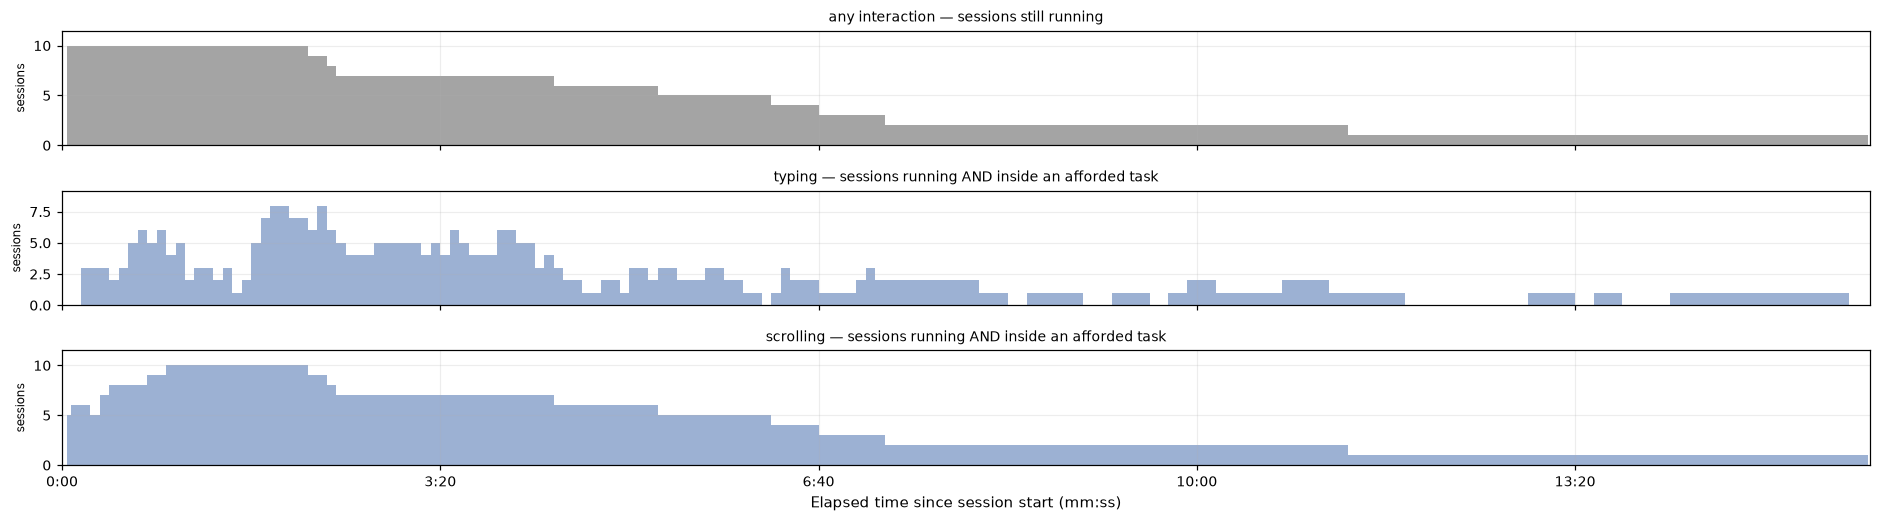

In [13]:
def plot_support_strips(sessions_meta, bin_s=PLOT_STRIDE_S, time_range_s=TIME_RANGE_S):
    mods = [None] + [m for m in AFFORDS if m != 'tapping' and AFFORDS[m]]
    fig, axes = plt.subplots(len(mods), 1, figsize=(17.2, 1.35 * len(mods) + 0.8),
                             sharex=True, squeeze=False)
    for ax, m in zip(axes.ravel(), mods):
        sup = session_support_by_bin(sessions_meta, bin_s, time_range_s, modality=m)
        ax.fill_between(sup['mid'], 0, sup['n'], step='mid',
                        color='0.35' if m is None else '#4c72b0', alpha=0.55, lw=0)
        ax.set_ylim(0, max(1, int(sup['n'].max())) * 1.15)
        ax.set_xlim(*time_range_s)
        ax.set_ylabel("sessions", fontsize=8)
        ax.set_title("any interaction — sessions still running" if m is None
                     else f"{m} — sessions running AND inside an afforded task", fontsize=9)
    axes.ravel()[-1].xaxis.set_major_formatter(plt.FuncFormatter(format_elapsed_mmss))
    axes.ravel()[-1].set_xlabel("Elapsed time since session start (mm:ss)")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


plot_support_strips(session_index)

## 8. The whole distribution, not the median

Empirical CDFs of the raw intervals on a log x-axis, per participant. This is the direct
answer to failure mode 2 at the top of the notebook: instead of collapsing each
participant to one number, plot every interval they produced and let the curves separate
wherever they separate.

A curve sitting to the **left** is a faster participant. The vertical spread between
curves at a given x is how strongly that interval discriminates at that timescale — and
for most of these it is widest in the right-hand tail, which is exactly the region a
median discards.

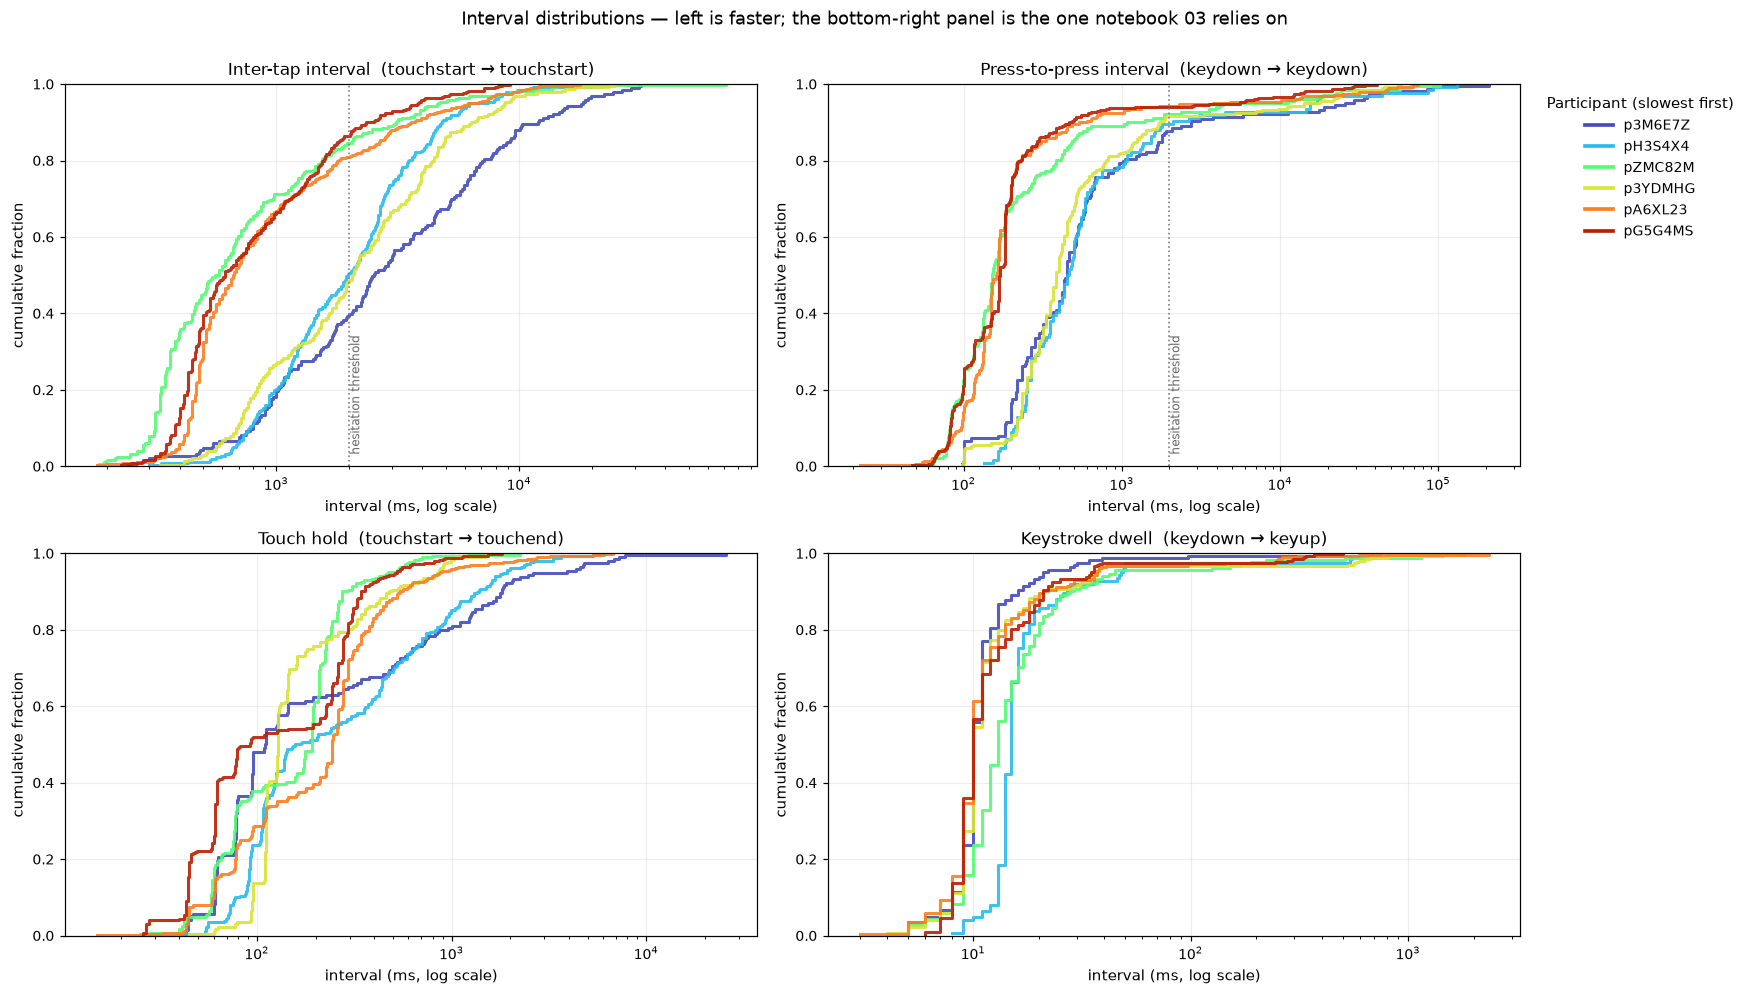

In [14]:
def all_intervals(raw_df, kind):
    out = []
    for sid, sub in raw_df.groupby('sessionId'):
        t = np.sort(sub.loc[sub['kind'] == kind, 'tRelMs'].to_numpy(float))
        if len(t) < 2:
            continue
        v = np.diff(t)
        out.append(pd.DataFrame({'participantId': sub['participantId'].iloc[0],
                                 'sessionId': sid, 'interval_ms': v[v > 0]}))
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


def all_holds(raw_df, start_kind, end_kind):
    out = []
    for sid, sub in raw_df.groupby('sessionId'):
        s = np.sort(sub.loc[sub['kind'] == start_kind, 'tRelMs'].to_numpy(float))
        e = np.sort(sub.loc[sub['kind'] == end_kind, 'tRelMs'].to_numpy(float))
        v = _paired_hold(s, e)
        v = v[v > 0]
        if len(v):
            out.append(pd.DataFrame({'participantId': sub['participantId'].iloc[0],
                                     'sessionId': sid, 'interval_ms': v}))
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


def plot_ecdf_panel(ax, d, title, ref_lines=()):
    for pid in PARTICIPANT_ORDER:
        v = np.sort(d.loc[d['participantId'] == pid, 'interval_ms'].to_numpy(float))
        v = v[v > 0]
        if len(v) < 5:
            continue
        ax.step(v, np.arange(1, len(v) + 1) / len(v), where='post',
                color=pcolor(pid), lw=2.0, alpha=0.9)
    for x, lab in ref_lines:
        ax.axvline(x, color='0.5', ls=':', lw=1.1)
        ax.text(x, 0.02, f" {lab}", fontsize=8, color='0.4', rotation=90, va='bottom')
    ax.set_xscale('log')
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel("cumulative fraction")
    ax.set_xlabel("interval (ms, log scale)")


def plot_interval_ecdfs(raw_df):
    panels = [
        ("Inter-tap interval  (touchstart → touchstart)", all_intervals(raw_df, TAP_KIND),
         [(IDLE_GAP_MS, 'hesitation threshold')]),
        ("Press-to-press interval  (keydown → keydown)", all_intervals(raw_df, KEY_KIND),
         [(IDLE_GAP_MS, 'hesitation threshold')]),
        ("Touch hold  (touchstart → touchend)", all_holds(raw_df, TAP_KIND, TAP_END_KIND), []),
        ("Keystroke dwell  (keydown → keyup)", all_holds(raw_df, KEY_KIND, KEYUP_KIND), []),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    for ax, (title, d, refs) in zip(axes.ravel(), panels):
        if d.empty:
            ax.set_title(f"{title} — no data"); ax.set_axis_off(); continue
        plot_ecdf_panel(ax, d, title, refs)
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANT_ORDER]
    axes[0, 1].legend(handles=handles, title="Participant (slowest first)",
                      bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    fig.suptitle("Interval distributions — left is faster; the bottom-right panel is "
                 "the one notebook 03 relies on", y=1.0)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


plot_interval_ecdfs(raw)

### 8.1 Why the dwell panel is flat

The bottom-right panel above is `typing_dwell_ms`, one of notebook 03's headline live
metrics. On mobile every participant's curve lands on top of every other's.

On a touchscreen there is no key travel: `keyup` follows `keydown` as fast as the browser
can dispatch the pair, so dwell largely measures event-loop latency rather than a finger.

The cell below quantifies it. **Be careful how far this is pushed**, though: dwell is not
worthless here. It is worthless for *this* contrast — the slow and fast participants have
identical medians — while still separating one participant (`pZMC82M`, median 13ms
against everyone else's 10ms) well enough to score above chance in Section 9. The honest
statement is that dwell carries a little identity and no pace, not that it carries
nothing.

What it does establish is the rule change for notebook 03's liveness gate: cardinality is
the wrong test. A feature can take 40 distinct values within every session and still sit
on top of every other participant's distribution.

In [15]:
_dwell = all_holds(raw, KEY_KIND, KEYUP_KIND)
if not _dwell.empty:
    q = (_dwell.groupby('participantId')['interval_ms']
         .agg(n='size', p25=lambda s: s.quantile(0.25), p50='median',
              p75=lambda s: s.quantile(0.75), n_unique='nunique')
         .round(1).reindex(PARTICIPANT_ORDER))
    print("Keystroke dwell on mobile, by participant (slowest first):")
    print(q.to_string())
    spread = q['p50'].max() - q['p50'].min()
    typical_iqr = (q['p75'] - q['p25']).median()
    print(f"\nSpread of participant medians: {spread:.1f} ms")
    print(f"Typical within-participant IQR:  {typical_iqr:.1f} ms")
    print(f"-> between-participant spread is {spread / typical_iqr:.2f}x the within-participant IQR."
          f"\n   Cardinality is high ({int(q['n_unique'].min())}-{int(q['n_unique'].max())} distinct values), "
          f"separation is not.")

Keystroke dwell on mobile, by participant (slowest first):
                 n   p25   p50   p75  n_unique
participantId                                 
p3M6E7Z        165  10.0  10.0  11.0        25
pH3S4X4        125  14.0  15.0  16.0        29
pZMC82M        182  11.0  13.0  18.0        39
p3YDMHG        268   9.0  10.0  12.0        37
pA6XL23        283   9.0  10.0  12.0        38
pG5G4MS        356   9.0  10.0  13.0        35

Spread of participant medians: 5.0 ms
Typical within-participant IQR:  3.0 ms
-> between-participant spread is 1.67x the within-participant IQR.
   Cardinality is high (25-39 distinct values), separation is not.


## 9. Could a single CA window tell them apart?

The operational question. Everything above uses whole sessions or 20-second windows; a
deployed system gets **7.5 seconds**.

For each feature, and each pair of participants, the score is the probability that a
randomly drawn window from one participant exceeds a randomly drawn window from the
other — the rank-based AUC of a single-feature classifier. 0.5 is chance; 1.0 is perfect
separation in that one feature alone. This is computed on `ca_windows`, at P2's real
7.5s/2.5s windowing.

Two things this does *not* establish. Overlapping windows within a session are
correlated, so these are not independent samples and the AUC is optimistic. And with
participants on distinct handsets, a high score is still consistent with device
separation rather than person separation.

**Read `auc_mean_all_pairs`, not just the contrast column.** The two are measuring
different things and they disagree in an instructive way. Tempo features dominate the
contrast pair, as the rest of this notebook argues they should. But averaged over *all*
participant pairs, `typing_dwell_p50` — the feature Section 8.1 just showed is useless
for the slow-vs-fast contrast — climbs back into the upper half, because it isolates one
participant the tempo features cannot. Pace and identity are not the same axis. A feature
that separates the extremes may do nothing for two people who happen to work at similar
speed, and the features worth keeping are the ones with a decent `auc_min_all_pairs`,
which is the worst pair rather than the easiest.

In [16]:
def pairwise_auc(win_df, features=ALL_FEATURES):
    parts = [p for p in PARTICIPANT_ORDER if p in set(win_df['participantId'])]
    rows = []
    for f in features:
        vals = {p: win_df.loc[win_df['participantId'] == p, f].to_numpy(float) for p in parts}
        pair_scores = {}
        for i, a in enumerate(parts):
            for b in parts[i + 1:]:
                auc = rank_auc(vals[a], vals[b])
                if np.isfinite(auc):
                    pair_scores[(a, b)] = max(auc, 1 - auc)  # direction-free separability
        if not pair_scores:
            continue
        contrast_key = ((CONTRAST_SLOW, CONTRAST_FAST) if (CONTRAST_SLOW, CONTRAST_FAST) in pair_scores
                        else (CONTRAST_FAST, CONTRAST_SLOW))
        rows.append({'feature': f,
                     'kind': 'tempo' if f in TEMPO_FEATURES else 'amplitude',
                     'auc_contrast_pair': pair_scores.get(contrast_key, np.nan),
                     'auc_mean_all_pairs': float(np.mean(list(pair_scores.values()))),
                     'auc_min_all_pairs': float(np.min(list(pair_scores.values()))),
                     'n_pairs': len(pair_scores)})
    return (pd.DataFrame(rows).sort_values('auc_mean_all_pairs', ascending=False)
            .reset_index(drop=True))


ca_auc = pairwise_auc(ca_windows)
print(f"Single-feature separability at {CA_WINDOW_S}s windows "
      f"({len(ca_windows):,} windows, {ca_windows['participantId'].nunique()} participants).")
print("auc_contrast_pair = the two participants named at the top; "
      "auc_mean_all_pairs = averaged over every participant pair.\n")
ca_auc.round(3)

Single-feature separability at 7.5s windows (1,511 windows, 6 participants).
auc_contrast_pair = the two participants named at the top; auc_mean_all_pairs = averaged over every participant pair.



,feature,kind,auc_contrast_pair,auc_mean_all_pairs,auc_min_all_pairs,n_pairs
0,press_to_press_p50,tempo,0.940,0.786,0.513,15
1,press_to_press_p90,tempo,0.951,0.780,0.546,15
2,typing_dwell_p50,amplitude,0.537,0.749,0.514,15
3,inter_tap_p50,tempo,0.822,0.716,0.515,15
4,tap_rate,tempo,0.927,0.707,0.525,15
5,longest_gap_s,tempo,0.876,0.664,0.511,15
6,key_rate,tempo,0.857,0.661,0.522,15
7,inter_tap_p90,tempo,0.695,0.656,0.515,15
8,interaction_rate,tempo,0.789,0.651,0.534,15
9,idle_fraction,tempo,0.852,0.651,0.501,15


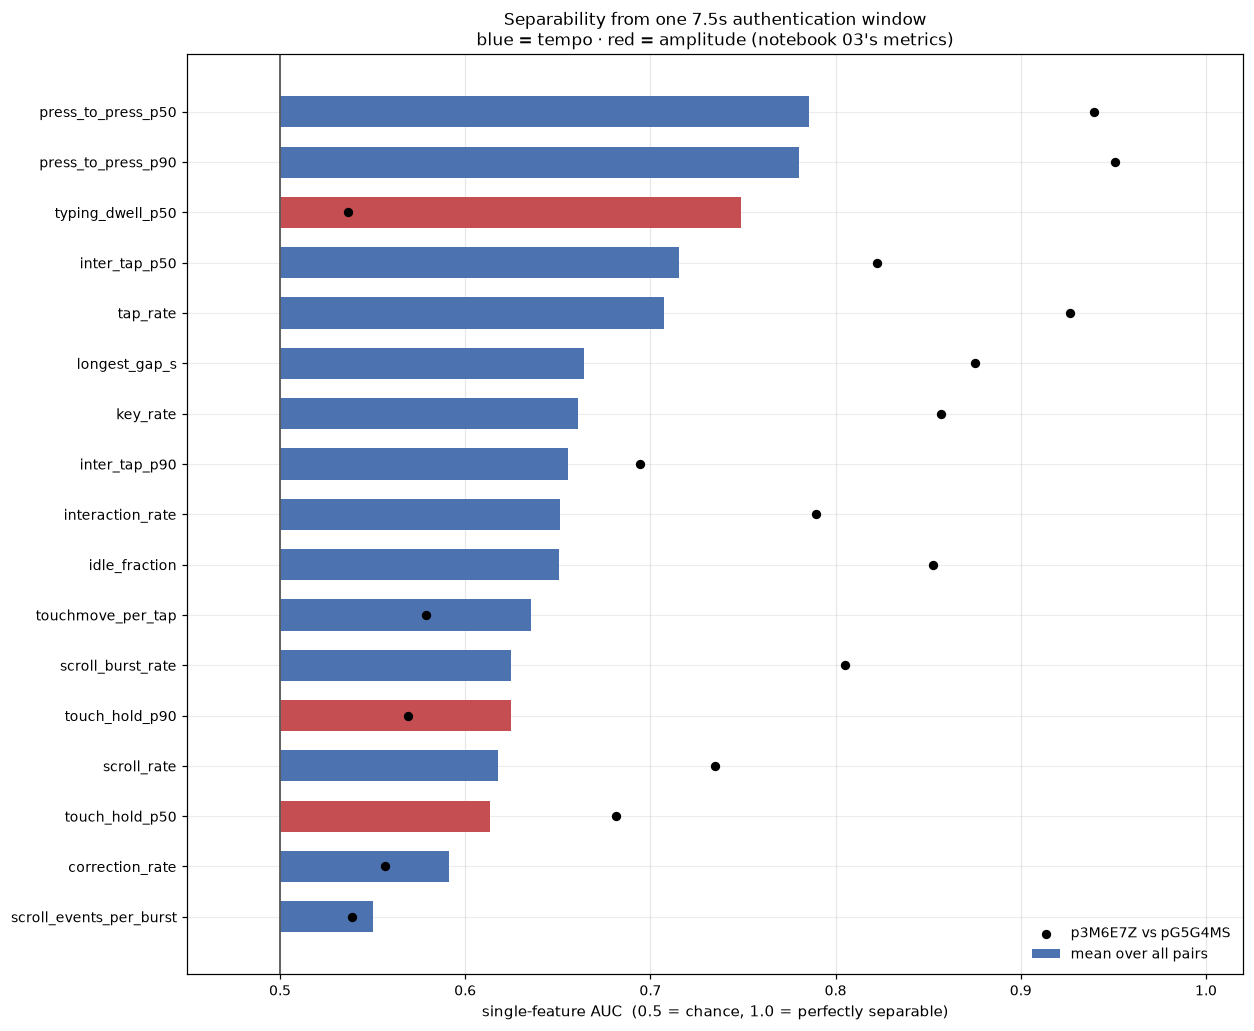

In [17]:
def plot_ca_auc(auc_df):
    d = auc_df.dropna(subset=['auc_mean_all_pairs']).sort_values('auc_mean_all_pairs')
    fig, ax = plt.subplots(figsize=(11.5, 0.44 * len(d) + 2))
    y = np.arange(len(d))
    colors = ['#c44e52' if k == 'amplitude' else '#4c72b0' for k in d['kind']]
    ax.barh(y, d['auc_mean_all_pairs'] - 0.5, left=0.5, color=colors, height=0.62,
            label='mean over all pairs')
    ax.scatter(d['auc_contrast_pair'], y, color='black', s=26, zorder=3,
               label=f"{CONTRAST_SLOW} vs {CONTRAST_FAST}")
    ax.axvline(0.5, color='0.35', lw=1.2)
    ax.set_yticks(y); ax.set_yticklabels(d['feature'])
    ax.set_xlim(0.45, 1.02)
    ax.set_xlabel("single-feature AUC  (0.5 = chance, 1.0 = perfectly separable)")
    ax.set_title(f"Separability from one {CA_WINDOW_S}s authentication window\n"
                 "blue = tempo · red = amplitude (notebook 03's metrics)")
    ax.legend(loc='lower right', frameon=False)
    ax.grid(True, axis='x', alpha=0.3); ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


plot_ca_auc(ca_auc)

## 10. Per-modality rhythm — typing, tapping, scrolling

The same story split by the three channels the question was about, so a modality-specific
model has something to be designed against. Each panel is a participant distribution at
CA window size; the point is which channel separates and by how much, not the absolute
values.

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_23702/2134847038.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, showfliers=False,
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_23702/2134847038.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, showfliers=False,
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_23702/2134847038.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, showfliers=False,
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_23702

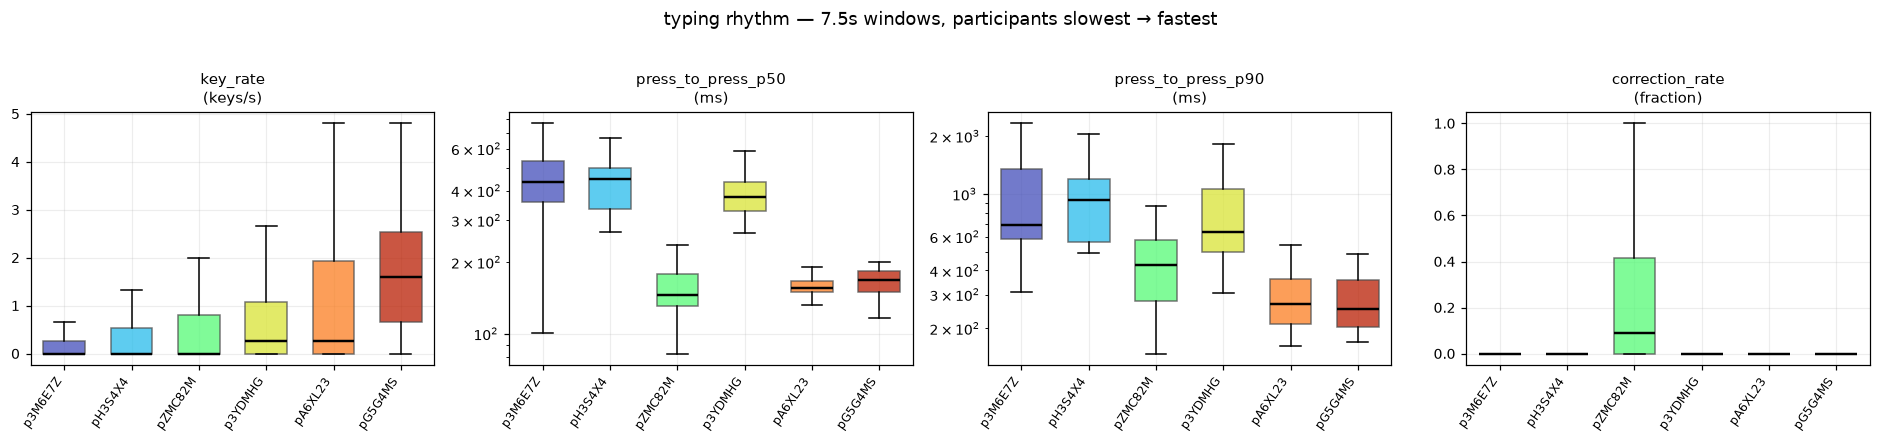

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_23702/2134847038.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, showfliers=False,
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_23702/2134847038.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, showfliers=False,
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_23702/2134847038.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, showfliers=False,
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_23702

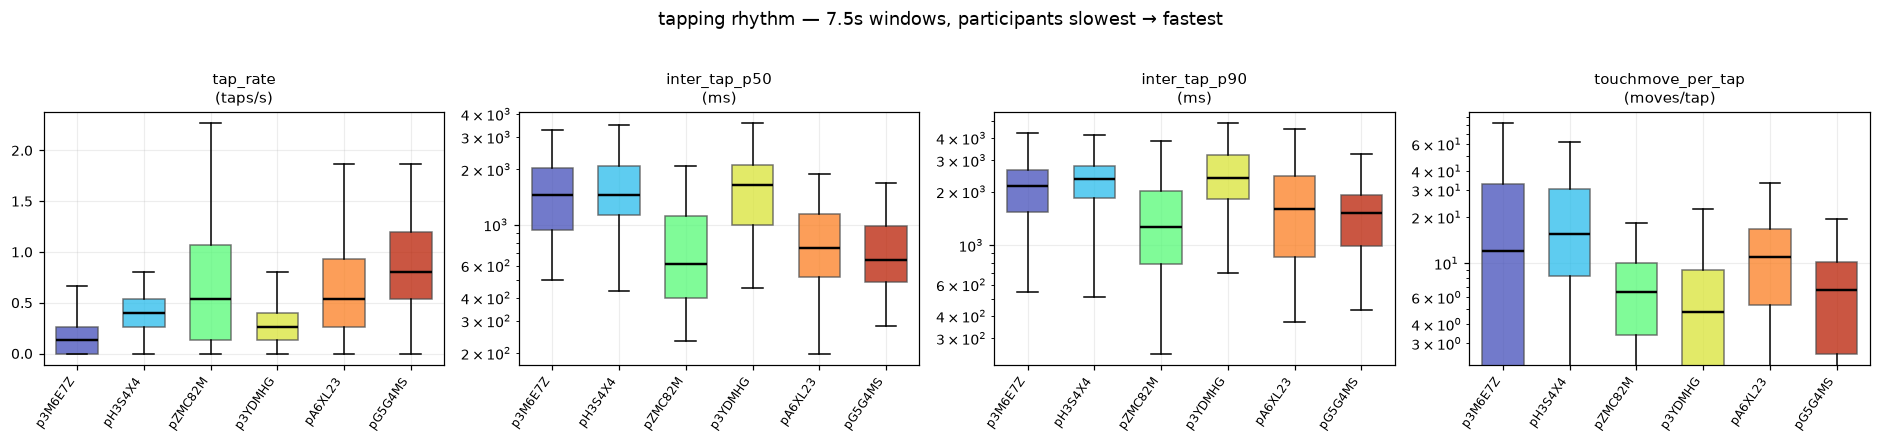

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_23702/2134847038.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, showfliers=False,
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_23702/2134847038.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, showfliers=False,
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_23702/2134847038.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, showfliers=False,
/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_23702

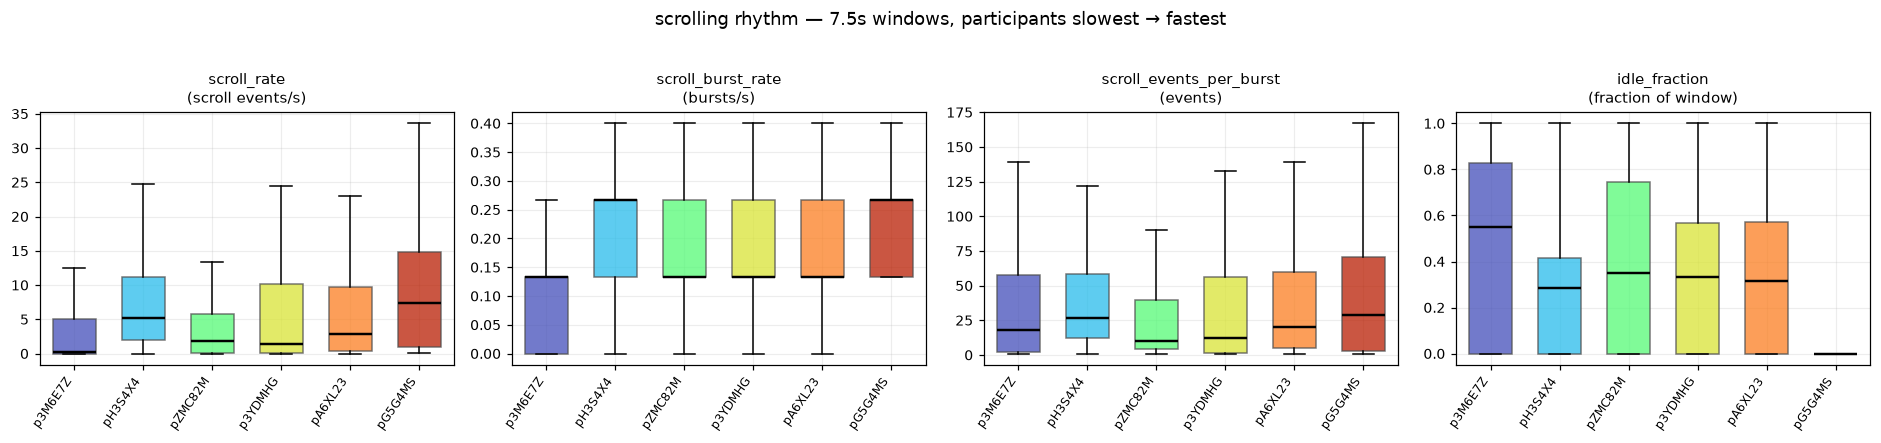

In [18]:
MODALITY_PANELS = {
    'typing': ['key_rate', 'press_to_press_p50', 'press_to_press_p90', 'correction_rate'],
    'tapping': ['tap_rate', 'inter_tap_p50', 'inter_tap_p90', 'touchmove_per_tap'],
    'scrolling': ['scroll_rate', 'scroll_burst_rate', 'scroll_events_per_burst', 'idle_fraction'],
}


def plot_modality_rhythm(win_df):
    for modality, feats in MODALITY_PANELS.items():
        fig, axes = plt.subplots(1, len(feats), figsize=(4.3 * len(feats), 3.9))
        axes = np.atleast_1d(axes)
        for ax, f in zip(axes, feats):
            data, labels, colors = [], [], []
            for p in PARTICIPANT_ORDER:
                v = win_df.loc[win_df['participantId'] == p, f].to_numpy(float)
                v = v[np.isfinite(v)]
                if len(v) < 5:
                    continue
                data.append(v); labels.append(p); colors.append(pcolor(p))
            if not data:
                ax.set_title(f"{f} — no data"); ax.set_axis_off(); continue
            bp = ax.boxplot(data, vert=True, patch_artist=True, showfliers=False,
                            widths=0.62, medianprops={'color': 'black', 'lw': 1.6})
            for patch, c in zip(bp['boxes'], colors):
                patch.set_facecolor(c); patch.set_alpha(0.75); patch.set_edgecolor('0.3')
            ax.set_xticks(range(1, len(labels) + 1))
            ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=8)
            if f in LOG_SCALE_FEATURES:
                allv = np.concatenate(data); pos = allv[allv > 0]
                if len(pos):
                    ax.set_yscale('log')
            ax.set_title(f"{f}\n({FEATURE_UNITS.get(f, '')})", fontsize=10)
        fig.suptitle(f"{modality} rhythm — {CA_WINDOW_S}s windows, participants slowest → fastest",
                     y=1.02)
        plt.tight_layout()
        plt.show()
        plt.close(fig)


plot_modality_rhythm(ca_windows)

## 11. Export and carry-forward

In [19]:
OUT_DIR = Path("../../data/interim")
OUT_DIR.mkdir(parents=True, exist_ok=True)

_exports = {
    'rhythm_session_features.csv': session_features,
    'rhythm_windows_plot.csv': plot_windows,
    'rhythm_windows_ca.csv': ca_windows,
    'rhythm_contrast_effect_sizes.csv': contrast,
    'rhythm_ca_window_auc.csv': ca_auc,
}
for name, frame in _exports.items():
    frame.to_csv(OUT_DIR / name, index=False)
    print(f"wrote {OUT_DIR / name}  ({len(frame):,} rows)")

wrote ../../data/interim/rhythm_session_features.csv  (10 rows)
wrote ../../data/interim/rhythm_windows_plot.csv  (734 rows)
wrote ../../data/interim/rhythm_windows_ca.csv  (1,511 rows)
wrote ../../data/interim/rhythm_contrast_effect_sizes.csv  (17 rows)
wrote ../../data/interim/rhythm_ca_window_auc.csv  (17 rows)


## 12. What this changes

**For `build_windows_dataset.py`.** The rhythm features in Section 5 are not in the
pipeline yet and every one of them is cheap — they need only event timestamps, which are
already in the canonical raw layer. The set worth adding first:

| Feature | Why |
|---|---|
| `idle_fraction`, `longest_gap_s` | Silence as a first-class observation. Nothing else in the pipeline can represent a pause. |
| `inter_tap_p50`, `inter_tap_p90` | Tapping rhythm. No inter-tap interval exists in the pipeline at all today. |
| `press_to_press_p90` | The tail, not just the median — hesitation lives here. |
| `interaction_rate`, `tap_rate`, `key_rate`, `scroll_rate` | Throughput. Currently unrepresentable, since every existing feature is per-event. |
| `touchmove_per_tap` | Finger steadiness during a tap. |
| `correction_rate` | Deletions per input, from `payload_deltaLength` — currently dropped by the liveness gate. |
| `scroll_burst_rate`, `scroll_events_per_burst` | Pecking vs flinging. |

**Add `_p90` alongside `_p50` for every interval-valued feature.** Notebook 03 is not
wrong to compute medians; it is wrong to compute *only* medians. The tail is where
hesitation is, and it costs one extra column.

**Two rule changes for notebook 03's liveness gate.** It currently tests cardinality
within a session, which passed `typing_dwell_ms` (a mobile platform constant with high
cardinality) and rejected `typing_delta_length` (low cardinality, but the corrections
signal). Cardinality answers "does this vary?"; the useful question is "does this vary
*between people* more than *within a person*?" Section 6's effect size is a usable
replacement, and low-cardinality signals should be admitted as rates rather than dropped.

**A caution about what this means for modelling.** Tempo features are strong here partly
because task pace and identity are entangled in this cohort: the slow participant is
slow at everything. That is genuine behavioural signal and a legitimate CA feature — but
a model leaning on it is closer to "recognises an unhurried person" than "recognises this
specific person", and it will be more exposed to state (tired, distracted, in a hurry)
than a motor-timing feature would be. Section 9's per-pair AUC is the thing to watch:
features that separate *every* pair, not just the extremes, are the ones carrying
identity rather than pace.

**The confound, restated.** Every participant here is on their own handset. Tempo is a
far less plausible device artefact than screen geometry or pointer dimensions, but it
is not immune — sluggish hardware produces sluggish traces. The multi-user-per-device
collection settles this, and until it lands every number above is provisional.
